# Inter-Patient TCN + RevIN (PyTorch)

**Author:** Ibrahim Hanafy  
**Date:** August 2026  

**Goal:** Train a single shared TCN + RevIN on pooled train patients, evaluate on unseen test patients.  
RevIN normalizes each input window by its own mean/std — handles inter-patient distribution shift without per-patient scalers.

**Setup:**
- **All MIT-BIH patients** — auto-discovered, randomly split **36 train / 12 test**
- **Horizon:** H=10 (multi-step, 10-step-ahead)
- **No MinMax normalization** — RevIN handles normalization at runtime
- **Framework:** PyTorch

**Hyperparameters (MOGWO Pareto-best, Eval 28):**

| Parameter | Value | Source |
|-----------|-------|--------|
| `n_filters` | 128 | MOGWO Pareto-best (RMSE) |
| `dropout` | 0.131 | MOGWO Pareto-best |
| `lr` | 0.00451 | MOGWO Pareto-best |
| `n_blocks` | 3 | Fixed (RF=29 ≫ lookback=10) |
| `kernel_size` | 3 | Fixed (Bai et al.) |
| `batch_size` | 128 | Fixed |
| `lookback` | 10 | Fixed (Dudukcu et al.) |

**Reference:** Kim et al. (2022) — Reversible Instance Normalization for Accurate Time-Series Forecasting against Distribution Shift (ICLR 2022)

---

## 1 — Imports & Setup

In [1]:
!pip install wfdb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.1 MB/s eta 0:00:00


In [2]:
import os, sys, time, gc, warnings, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import wilcoxon
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings('ignore')

# ── RevIN (Kim et al., ICLR 2022) — inlined to avoid import issues ──────────
class RevIN(nn.Module):
    """Reversible Instance Normalization.
    Reference: Kim et al. (2022) — ICLR 2022.
    """
    def __init__(self, num_features: int, eps=1e-5, affine=True):
        super(RevIN, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.affine = affine
        if self.affine:
            self._init_params()

    def forward(self, x, mode: str):
        if mode == 'norm':
            self._get_statistics(x)
            x = self._normalize(x)
        elif mode == 'denorm':
            x = self._denormalize(x)
        else:
            raise NotImplementedError
        return x

    def _init_params(self):
        self.affine_weight = nn.Parameter(torch.ones(self.num_features))
        self.affine_bias = nn.Parameter(torch.zeros(self.num_features))

    def _get_statistics(self, x):
        dim2reduce = tuple(range(1, x.ndim - 1))
        self.mean = torch.mean(x, dim=dim2reduce, keepdim=True).detach()
        self.stdev = torch.sqrt(
            torch.var(x, dim=dim2reduce, keepdim=True, unbiased=False) + self.eps
        ).detach()

    def _normalize(self, x):
        x = x - self.mean
        x = x / self.stdev
        if self.affine:
            x = x * self.affine_weight
            x = x + self.affine_bias
        return x

    def _denormalize(self, x):
        if self.affine:
            x = x - self.affine_bias
            x = x / (self.affine_weight + self.eps * self.eps)
        x = x * self.stdev
        x = x + self.mean
        return x

print(f'PyTorch {torch.__version__}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print('RevIN defined (inlined).')

PyTorch 2.10.0+cu128
Device: cuda
GPU: Tesla T4
RevIN defined (inlined).


## 2 — Configuration

In [3]:
# ── Dataset ──────────────────────────────────────────────────────────────────
DATA_DIR = r"/kaggle/input/datasets/rracer17/mit-bih-mitdb/mit-bih-arrhythmia-database-1.0.0"

FS           = 360
TOTAL_STEPS  = 100_000
LOOKBACK     = 10
HORIZON      = 10

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Auto-discover ALL patients ────────────────────────────────────────────────
ALL_PATIENTS = sorted(set(
    os.path.splitext(os.path.basename(f))[0]
    for f in glob.glob(os.path.join(DATA_DIR, '*.hea'))
))
print(f'Discovered {len(ALL_PATIENTS)} patients: {ALL_PATIENTS}')

# ── Random 36/12 train/test split ─────────────────────────────────────────────
N_TEST = 12
shuffled = np.random.permutation(ALL_PATIENTS).tolist()
TEST_PATIENTS  = sorted(shuffled[:N_TEST])
TRAIN_PATIENTS = sorted(shuffled[N_TEST:])

print(f'\nTrain patients ({len(TRAIN_PATIENTS)}): {TRAIN_PATIENTS}')
print(f'Test  patients ({len(TEST_PATIENTS)}):  {TEST_PATIENTS}')

# ── MOGWO-Optimized Hyperparameters ───────────────────────────────────────────
NUM_FILTERS   = 128
DROPOUT_RATE  = 0.131
LEARNING_RATE = 0.00451
NUM_BLOCKS    = 3      # RF = 29 ≫ lookback=10
KERNEL_SIZE   = 3
BATCH_SIZE    = 128

# ── Training ─────────────────────────────────────────────────────────────────
EPOCHS   = 200
PATIENCE = 50
VAL_RATIO = 0.2  # 80/20 within each train patient (for early stopping)

# ── Output ───────────────────────────────────────────────────────────────────
OUT_DIR  = '/kaggle/working'
PLOT_DIR = os.path.join(OUT_DIR, 'plots_inter_tcn_revin_pytorch')
os.makedirs(PLOT_DIR, exist_ok=True)

# ── 10 random test patients for signal visualization ──────────────────────────
VIZ_PATIENTS = sorted(np.random.choice(
    TEST_PATIENTS, size=min(10, len(TEST_PATIENTS)), replace=False).tolist())

print(f'\nInter-Patient TCN + RevIN (PyTorch)')
print(f'Viz sample  : {len(VIZ_PATIENTS)} → {VIZ_PATIENTS}')
print(f'Horizon     : H={HORIZON}, Lookback={LOOKBACK}')
print(f'TCN         : blocks={NUM_BLOCKS} (RF=29), filters={NUM_FILTERS}, kernel={KERNEL_SIZE}')
print(f'Dropout={DROPOUT_RATE}, LR={LEARNING_RATE}, Batch={BATCH_SIZE}')
print(f'Training    : epochs={EPOCHS}, patience={PATIENCE}')

Discovered 48 patients: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']

Train patients (36): ['100', '101', '102', '105', '106', '107', '109', '111', '112', '114', '115', '116', '117', '118', '119', '122', '123', '124', '200', '207', '208', '209', '210', '212', '213', '214', '215', '217', '220', '221', '223', '228', '231', '232', '233', '234']
Test  patients (12):  ['103', '104', '108', '113', '121', '201', '202', '203', '205', '219', '222', '230']

Inter-Patient TCN + RevIN (PyTorch)
Viz sample  : 10 → ['103', '108', '113', '121', '201', '202', '203', '219', '222', '230']
Horizon     : H=10, Lookback=10
TCN         : blocks=3 (RF=29), filters=128, kernel=3
Dropout=0.131, LR=0.00451, Batch=128
Trainin

## 3 — Data Pipeline

**No MinMax normalization** — RevIN handles per-instance normalization at runtime.  
Raw signals pooled from train patients. Test patients evaluated separately.

**Val split (80/20):** Each train patient's signal is temporally split — last 20% used as validation for early stopping. Test patients are completely unseen (no overlap).

In [4]:
def load_ecg_signal(record_id, data_dir, n_steps=100_000):
    """Load MLII lead from MIT-BIH, truncate/pad to n_steps."""
    path = os.path.join(data_dir, record_id)
    rec  = wfdb.rdrecord(path)
    sig_names_upper = [s.upper() for s in rec.sig_name]
    ch = sig_names_upper.index('MLII') if 'MLII' in sig_names_upper else 0
    signal = rec.p_signal[:, ch].astype(np.float32)
    if len(signal) < n_steps:
        pad = np.full(n_steps - len(signal), signal[-1], dtype=np.float32)
        signal = np.concatenate([signal, pad])
    return signal[:n_steps]


def make_sequences(signal, lookback, horizon):
    """Sliding-window: X = (lookback,) -> y = (horizon,)."""
    X, y = [], []
    for i in range(len(signal) - lookback - horizon + 1):
        X.append(signal[i : i + lookback])
        y.append(signal[i + lookback : i + lookback + horizon])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def compute_metrics(y_true, y_pred):
    yt, yp = y_true.flatten(), y_pred.flatten()
    return {
        'RMSE': float(np.sqrt(mean_squared_error(yt, yp))),
        'MAE':  float(mean_absolute_error(yt, yp)),
        'R2':   float(r2_score(yt, yp)),
    }


print('Data functions defined.')

Data functions defined.


In [5]:
# ── Load raw signals (NO normalization — RevIN handles it) ─────────────────
raw_signals = {}
print(f'Loading {len(ALL_PATIENTS)} patients (raw, no normalization)...\n')
for rid in tqdm(ALL_PATIENTS, desc='Loading'):
    raw_signals[rid] = load_ecg_signal(rid, DATA_DIR, TOTAL_STEPS)
    tqdm.write(f'  Patient {rid:>3s} | samples={len(raw_signals[rid]):,}')

# ── Signal statistics (showing inter-patient distribution shift) ────────────
print(f'\n--- Signal Statistics (inter-patient distribution shift) ---')
print(f'{"Split":>6} {"Patient":>8} {"Mean":>10} {"Std":>10} {"Min":>10} {"Max":>10}')
print('-' * 58)
for rid in TRAIN_PATIENTS:
    s = raw_signals[rid]
    print(f'{"TRAIN":>6} {rid:>8} {s.mean():>10.2f} {s.std():>10.2f} '
          f'{s.min():>10.2f} {s.max():>10.2f}')
for rid in TEST_PATIENTS:
    s = raw_signals[rid]
    print(f'{"TEST":>6} {rid:>8} {s.mean():>10.2f} {s.std():>10.2f} '
          f'{s.min():>10.2f} {s.max():>10.2f}')

print(f'\nLoaded {len(raw_signals)} patients.')

Loading 48 patients (raw, no normalization)...



Loading:   0%|          | 0/48 [00:00<?, ?it/s]

  Patient 100 | samples=100,000
  Patient 101 | samples=100,000
  Patient 102 | samples=100,000
  Patient 103 | samples=100,000
  Patient 104 | samples=100,000
  Patient 105 | samples=100,000
  Patient 106 | samples=100,000
  Patient 107 | samples=100,000
  Patient 108 | samples=100,000
  Patient 109 | samples=100,000
  Patient 111 | samples=100,000
  Patient 112 | samples=100,000
  Patient 113 | samples=100,000
  Patient 114 | samples=100,000
  Patient 115 | samples=100,000
  Patient 116 | samples=100,000
  Patient 117 | samples=100,000
  Patient 118 | samples=100,000
  Patient 119 | samples=100,000
  Patient 121 | samples=100,000
  Patient 122 | samples=100,000
  Patient 123 | samples=100,000
  Patient 124 | samples=100,000
  Patient 200 | samples=100,000
  Patient 201 | samples=100,000
  Patient 202 | samples=100,000
  Patient 203 | samples=100,000
  Patient 205 | samples=100,000
  Patient 207 | samples=100,000
  Patient 208 | samples=100,000
  Patient 209 | samples=100,000
  Patien

In [6]:
# ── Build inter-patient datasets ──────────────────────────────────────────────
# Pool train patients, 80/20 split for train/val
# NO normalization — raw signals

X_train_all, y_train_all = [], []
X_val_all, y_val_all = [], []

for rid in TRAIN_PATIENTS:
    signal = raw_signals[rid]
    split_idx = int(len(signal) * (1 - VAL_RATIO))
    train_sig = signal[:split_idx]
    val_sig   = signal[split_idx:]

    X_tr, y_tr = make_sequences(train_sig, LOOKBACK, HORIZON)
    X_vl, y_vl = make_sequences(val_sig,   LOOKBACK, HORIZON)

    X_train_all.append(X_tr)
    y_train_all.append(y_tr)
    X_val_all.append(X_vl)
    y_val_all.append(y_vl)

X_train = np.concatenate(X_train_all)
y_train = np.concatenate(y_train_all)
X_val   = np.concatenate(X_val_all)
y_val   = np.concatenate(y_val_all)

print(f'Pooled train: {X_train.shape[0]:,} sequences from {len(TRAIN_PATIENTS)} patients')
print(f'Pooled val:   {X_val.shape[0]:,} sequences')

# Build test data per patient
test_data = {}
for rid in TEST_PATIENTS:
    X_te, y_te = make_sequences(raw_signals[rid], LOOKBACK, HORIZON)
    test_data[rid] = (X_te, y_te)
    print(f'Test patient {rid}: {X_te.shape[0]:,} sequences')

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)  # (N, lookback, 1)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32).unsqueeze(-1)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'\nTrain batches: {len(train_loader):,}  Val batches: {len(val_loader):,}')

# Free numpy arrays
del X_train_all, y_train_all, X_val_all, y_val_all
del X_train, y_train, X_val, y_val
gc.collect()

print('Datasets ready.')

Pooled train: 2,879,316 sequences from 36 patients
Pooled val:   719,316 sequences
Test patient 103: 99,981 sequences
Test patient 104: 99,981 sequences
Test patient 108: 99,981 sequences
Test patient 113: 99,981 sequences
Test patient 121: 99,981 sequences
Test patient 201: 99,981 sequences
Test patient 202: 99,981 sequences
Test patient 203: 99,981 sequences
Test patient 205: 99,981 sequences
Test patient 219: 99,981 sequences
Test patient 222: 99,981 sequences
Test patient 230: 99,981 sequences

Train batches: 22,495  Val batches: 5,620
Datasets ready.


## 4 — Model Architecture

**TCN with RevIN** in PyTorch.  
- Residual blocks with dilated causal convolutions (Bai et al. 2018)
- RevIN wraps the TCN: normalize input per-window, denormalize output
- 3 blocks × dilation [1, 2, 4] → receptive field = 29

In [7]:
class CausalConv1d(nn.Module):
    """Conv1D with causal (left) padding."""

    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super().__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size,
                              dilation=dilation)

    def forward(self, x):
        # x: (batch, channels, seq_len)
        x = nn.functional.pad(x, (self.padding, 0))
        return self.conv(x)


class ResidualBlock(nn.Module):
    """TCN residual block: 2× (CausalConv → BN → ReLU → Dropout) + skip."""

    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout):
        super().__init__()
        self.conv1 = CausalConv1d(in_channels, out_channels, kernel_size, dilation)
        self.bn1   = nn.BatchNorm1d(out_channels)
        self.conv2 = CausalConv1d(out_channels, out_channels, kernel_size, dilation)
        self.bn2   = nn.BatchNorm1d(out_channels)
        self.relu  = nn.ReLU()
        self.drop  = nn.Dropout(dropout)

        # 1×1 conv for channel matching
        self.skip = (nn.Conv1d(in_channels, out_channels, 1)
                     if in_channels != out_channels else nn.Identity())

    def forward(self, x):
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        out = self.drop(self.relu(self.bn2(self.conv2(out))))
        return out + self.skip(x)


class TCNRevIN(nn.Module):
    """TCN wrapped with Reversible Instance Normalization.

    RevIN normalizes each input window by its own mean/std before the TCN,
    then denormalizes the output back to the original scale.
    """

    def __init__(self, lookback, horizon, n_blocks, n_filters,
                 kernel_size, dropout):
        super().__init__()
        self.revin = RevIN(num_features=1, affine=True)

        # TCN backbone
        blocks = []
        for i in range(n_blocks):
            in_ch = 1 if i == 0 else n_filters
            blocks.append(ResidualBlock(in_ch, n_filters, kernel_size,
                                       dilation=2**i, dropout=dropout))
        self.tcn = nn.Sequential(*blocks)

        # Head: last timestep → dense → output
        self.head = nn.Sequential(
            nn.Linear(n_filters, n_filters),
            nn.ReLU(),
            nn.Linear(n_filters, horizon),
        )

    def forward(self, x):
        # x: (batch, lookback, 1)

        # ── RevIN: normalize ──────────────────────────────────────────────
        x = self.revin(x, 'norm')

        # ── TCN backbone (expects channels-first) ─────────────────────────
        x = x.permute(0, 2, 1)        # (batch, 1, lookback)
        x = self.tcn(x)                # (batch, n_filters, lookback)
        x = x[:, :, -1]               # last timestep → (batch, n_filters)

        # ── Head ──────────────────────────────────────────────────────────
        out = self.head(x)             # (batch, horizon)

        # ── RevIN: denormalize ────────────────────────────────────────────
        out = out.unsqueeze(-1)        # (batch, horizon, 1) for RevIN
        out = self.revin(out, 'denorm')
        out = out.squeeze(-1)          # (batch, horizon)

        return out


# ── Sanity check ──────────────────────────────────────────────────────────────
model_test = TCNRevIN(LOOKBACK, HORIZON, NUM_BLOCKS, NUM_FILTERS,
                      KERNEL_SIZE, DROPOUT_RATE)
n_params = sum(p.numel() for p in model_test.parameters())
print(f'TCN + RevIN: {n_params:,} parameters')

# Test forward pass
dummy = torch.randn(4, LOOKBACK, 1)
out = model_test(dummy)
print(f'Input:  {dummy.shape}')
print(f'Output: {out.shape}')
assert out.shape == (4, HORIZON), f'Expected (4, {HORIZON}), got {out.shape}'
print('Forward pass OK.')

del model_test, dummy, out

TCN + RevIN: 266,508 parameters
Input:  torch.Size([4, 10, 1])
Output: torch.Size([4, 10])
Forward pass OK.


## 5 — Training

In [8]:
def train_model(model, train_loader, val_loader, epochs, lr, patience, device):
    """Train PyTorch model with early stopping + ReduceLROnPlateau."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=25, min_lr=1e-6)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    best_state    = None
    patience_ctr  = 0
    history       = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches  += 1
        avg_train = epoch_loss / n_batches
        history['train_loss'].append(avg_train)

        # --- Validation ---
        model.eval()
        val_loss, n_val = 0.0, 0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                val_loss += criterion(model(X_b), y_b).item()
                n_val    += 1
        avg_val = val_loss / n_val
        history['val_loss'].append(avg_val)

        # Step scheduler
        scheduler.step(avg_val)
        cur_lr = optimizer.param_groups[0]['lr']

        # --- Early stopping ---
        marker = ''
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
            marker = ' ★'
        else:
            patience_ctr += 1
            marker = f' (patience {patience_ctr}/{patience})'

        print(f'  Epoch {epoch+1:3d}/{epochs} — '
              f'train: {avg_train:.6f}  val: {avg_val:.6f}  '
              f'lr: {cur_lr:.2e}{marker}')

        if patience_ctr >= patience:
            print(f'  Early stopping at epoch {epoch+1}')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


def evaluate_on_patients(model, test_data, device, batch_size=2048):
    """Evaluate model on each test patient separately."""
    model.eval()
    results = []
    predictions = {}

    for rid, (X_te, y_te) in test_data.items():
        X_t = torch.tensor(X_te, dtype=torch.float32).unsqueeze(-1).to(device)

        preds = []
        with torch.no_grad():
            for i in range(0, len(X_t), batch_size):
                preds.append(model(X_t[i:i+batch_size]).cpu().numpy())
        y_pred = np.concatenate(preds, axis=0)

        m = compute_metrics(y_te, y_pred)
        m['Patient'] = rid
        results.append(m)
        predictions[rid] = (y_te, y_pred)

        print(f'    Patient {rid} | '
              f'RMSE={m["RMSE"]:.6f}  MAE={m["MAE"]:.6f}  '
              f'R²={m["R2"]:.4f}')

    return pd.DataFrame(results), predictions


print('Training and evaluation functions defined.')

Training and evaluation functions defined.


In [9]:
# ── Train TCN + RevIN ─────────────────────────────────────────────────────────
print('=' * 80)
print('  Inter-Patient TCN + RevIN (PyTorch)')
print('=' * 80)

torch.manual_seed(SEED)
np.random.seed(SEED)

model = TCNRevIN(LOOKBACK, HORIZON, NUM_BLOCKS, NUM_FILTERS,
                 KERNEL_SIZE, DROPOUT_RATE)

n_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {n_params:,}')
print(f'Train batches: {len(train_loader):,}  Val batches: {len(val_loader):,}')
print()

t0 = time.time()
model, history = train_model(
    model, train_loader, val_loader,
    epochs=EPOCHS, lr=LEARNING_RATE,
    patience=PATIENCE, device=DEVICE
)
train_time = time.time() - t0

ep_trained = len(history['train_loss'])
best_val = min(history['val_loss'])
print(f'\nTraining complete: {ep_trained} epochs, {train_time:.1f}s')
print(f'Best val_loss: {best_val:.6f}')

  Inter-Patient TCN + RevIN (PyTorch)
Parameters: 266,508
Train batches: 22,495  Val batches: 5,620

  Epoch   1/200 — train: 0.041022  val: 0.037381  lr: 4.51e-03 ★
  Epoch   2/200 — train: 0.036824  val: 0.036011  lr: 4.51e-03 ★
  Epoch   3/200 — train: 0.035728  val: 0.035344  lr: 4.51e-03 ★
  Epoch   4/200 — train: 0.035012  val: 0.035024  lr: 4.51e-03 ★
  Epoch   5/200 — train: 0.034593  val: 0.034069  lr: 4.51e-03 ★
  Epoch   6/200 — train: 0.034254  val: 0.033302  lr: 4.51e-03 ★
  Epoch   7/200 — train: 0.033955  val: 0.033611  lr: 4.51e-03 (patience 1/50)
  Epoch   8/200 — train: 0.033794  val: 0.033418  lr: 4.51e-03 (patience 2/50)
  Epoch   9/200 — train: 0.033547  val: 0.033291  lr: 4.51e-03 ★
  Epoch  10/200 — train: 0.033325  val: 0.033301  lr: 4.51e-03 (patience 1/50)
  Epoch  11/200 — train: 0.033335  val: 0.034209  lr: 4.51e-03 (patience 2/50)
  Epoch  12/200 — train: 0.033169  val: 0.032769  lr: 4.51e-03 ★
  Epoch  13/200 — train: 0.032991  val: 0.033418  lr: 4.51e-03 

In [10]:
# ── Evaluate on unseen test patients ──────────────────────────────────────────
print(f'\nEvaluating on {len(TEST_PATIENTS)} unseen test patients:\n')
df_results, predictions = evaluate_on_patients(model, test_data, DEVICE)

print(f'\n--- TCN + RevIN Summary (H={HORIZON}) ---')
print(f'Mean RMSE : {df_results.RMSE.mean():.6f} ± {df_results.RMSE.std():.6f}')
print(f'Mean MAE  : {df_results.MAE.mean():.6f} ± {df_results.MAE.std():.6f}')
print(f'Mean R²   : {df_results.R2.mean():.4f} ± {df_results.R2.std():.4f}')
print(f'Train time: {train_time:.1f}s ({ep_trained} epochs)')

# Save results
csv_path = os.path.join(OUT_DIR, f'inter_patient_tcn_revin_pytorch_h{HORIZON}.csv')
df_results.to_csv(csv_path, index=False)
print(f'\nResults saved to {csv_path}')
display(df_results)


Evaluating on 12 unseen test patients:

    Patient 103 | RMSE=0.203542  MAE=0.065998  R²=0.6014
    Patient 104 | RMSE=0.245834  MAE=0.100934  R²=0.3122
    Patient 108 | RMSE=0.122362  MAE=0.057043  R²=0.5623
    Patient 113 | RMSE=0.245331  MAE=0.074398  R²=0.7032
    Patient 121 | RMSE=0.098183  MAE=0.042733  R²=0.8796
    Patient 201 | RMSE=0.106407  MAE=0.043673  R²=0.6974
    Patient 202 | RMSE=0.102302  MAE=0.039980  R²=0.8143
    Patient 203 | RMSE=0.228593  MAE=0.101535  R²=0.7570
    Patient 205 | RMSE=0.114119  MAE=0.044693  R²=0.5958
    Patient 219 | RMSE=0.190856  MAE=0.069223  R²=0.8167
    Patient 222 | RMSE=0.133665  MAE=0.045423  R²=0.1485
    Patient 230 | RMSE=0.218719  MAE=0.085954  R²=0.6529

--- TCN + RevIN Summary (H=10) ---
Mean RMSE : 0.167493 ± 0.059707
Mean MAE  : 0.064299 ± 0.022567
Mean R²   : 0.6284 ± 0.2126
Train time: 33574.5s (200 epochs)

Results saved to /kaggle/working/inter_patient_tcn_revin_pytorch_h10.csv


,RMSE,MAE,R2,Patient
0,0.203542,0.065998,0.601403,103
1,0.245834,0.100934,0.312175,104
2,0.122362,0.057043,0.562265,108
3,0.245331,0.074398,0.703150,113
4,0.098183,0.042733,0.879635,121
5,0.106407,0.043673,0.697396,201
6,0.102302,0.039980,0.814349,202
7,0.228593,0.101535,0.756963,203
8,0.114119,0.044693,0.595788,205
9,0.190856,0.069223,0.816749,219


## 6 — Per-Patient Metric Bar Charts

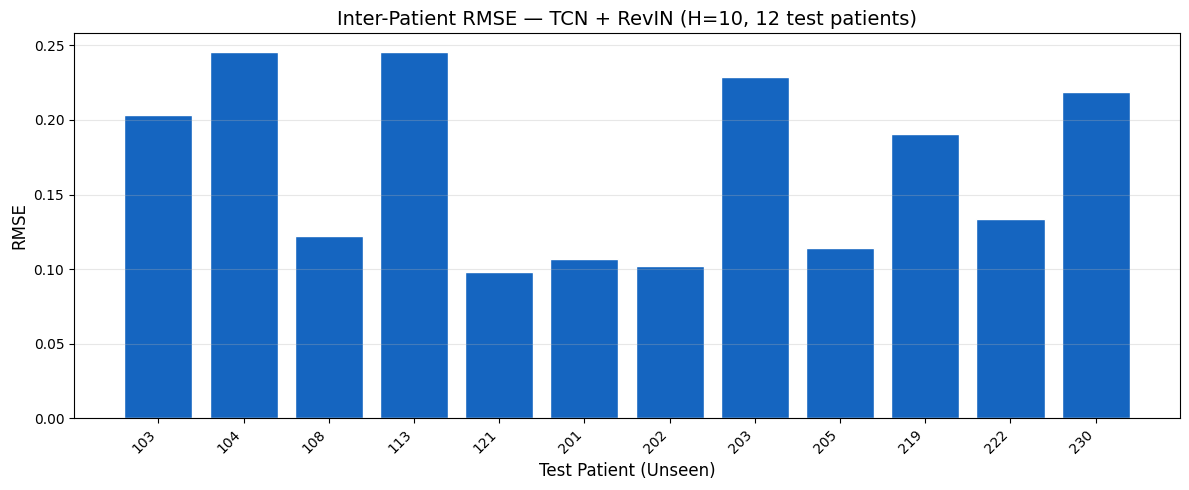

In [11]:
# ── 6.1 RMSE Bar Chart ───────────────────────────────────────────────────────
df_sorted = df_results.sort_values('Patient').reset_index(drop=True)
x = np.arange(len(TEST_PATIENTS))

fig, ax = plt.subplots(figsize=(max(12, len(TEST_PATIENTS) * 0.8), 5))
ax.bar(x, df_sorted.RMSE.values, color='#1565C0', edgecolor='white')
ax.set_xlabel('Test Patient (Unseen)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title(f'Inter-Patient RMSE — TCN + RevIN (H={HORIZON}, '
             f'{len(TEST_PATIENTS)} test patients)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df_sorted.Patient.values, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'bar_rmse.png'), dpi=200, bbox_inches='tight')
plt.show()

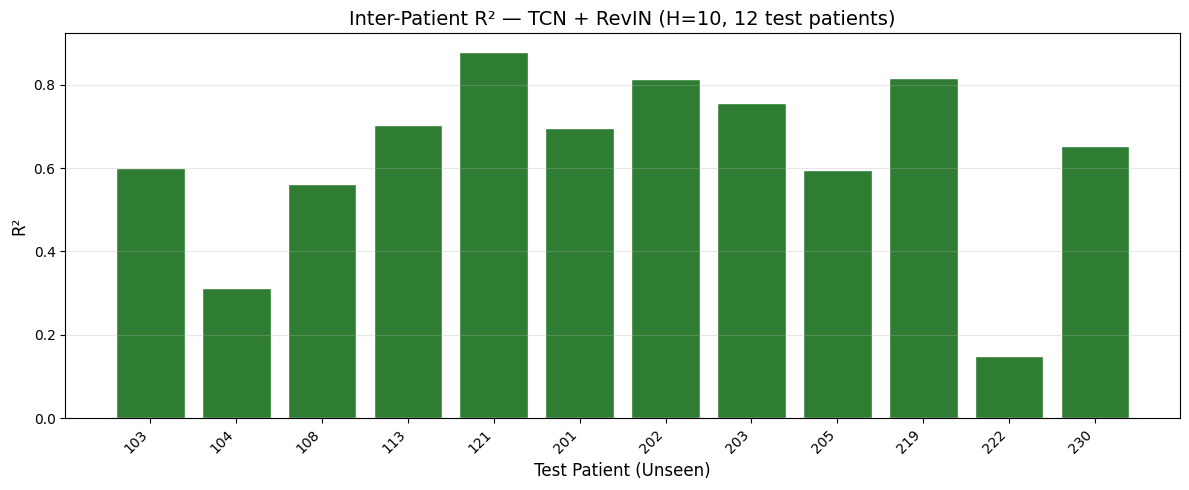

In [12]:
# ── 6.2 R² Bar Chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(12, len(TEST_PATIENTS) * 0.8), 5))
ax.bar(x, df_sorted.R2.values, color='#2E7D32', edgecolor='white')
ax.set_xlabel('Test Patient (Unseen)', fontsize=12)
ax.set_ylabel('R²', fontsize=12)
ax.set_title(f'Inter-Patient R² — TCN + RevIN (H={HORIZON}, '
             f'{len(TEST_PATIENTS)} test patients)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df_sorted.Patient.values, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'bar_r2.png'), dpi=200, bbox_inches='tight')
plt.show()

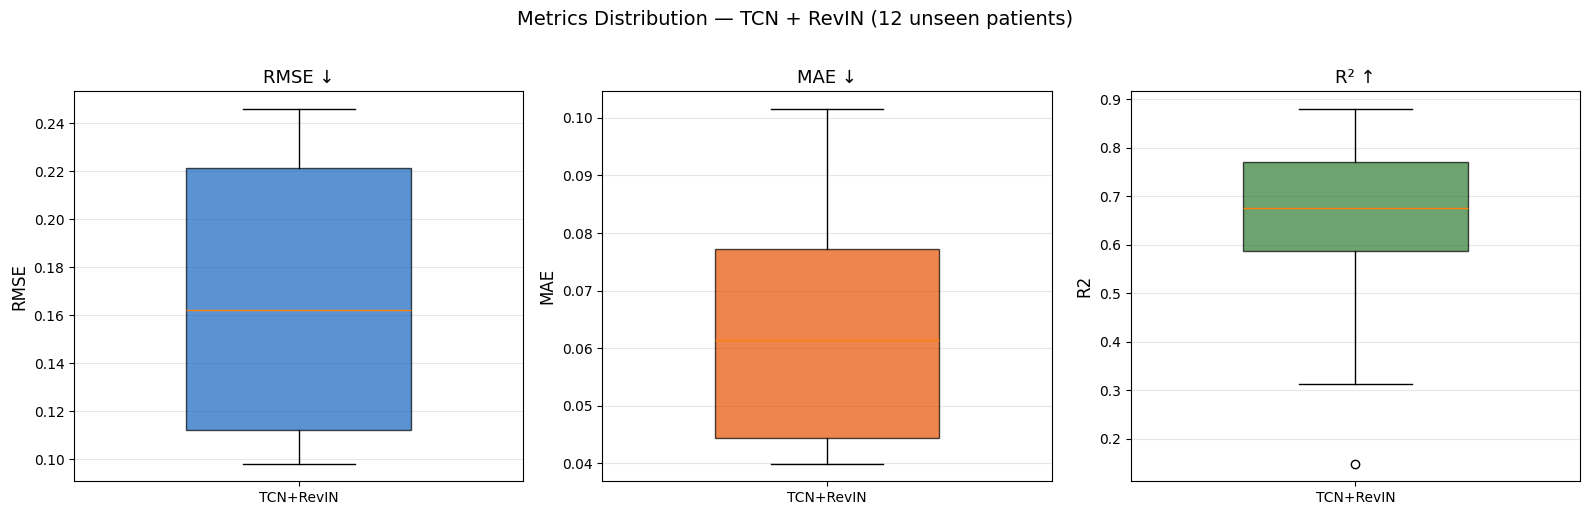

In [13]:
# ── 6.3 Metrics Box Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, title, color in zip(
    axes,
    ['RMSE', 'MAE', 'R2'],
    ['RMSE ↓', 'MAE ↓', 'R² ↑'],
    ['#1565C0', '#E65100', '#2E7D32']
):
    bp = ax.boxplot(df_results[metric].values, patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.set_xticklabels(['TCN+RevIN'])
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'Metrics Distribution — TCN + RevIN ({len(TEST_PATIENTS)} unseen patients)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'metrics_boxplots.png'), dpi=200, bbox_inches='tight')
plt.show()

## 7 — Training Curves

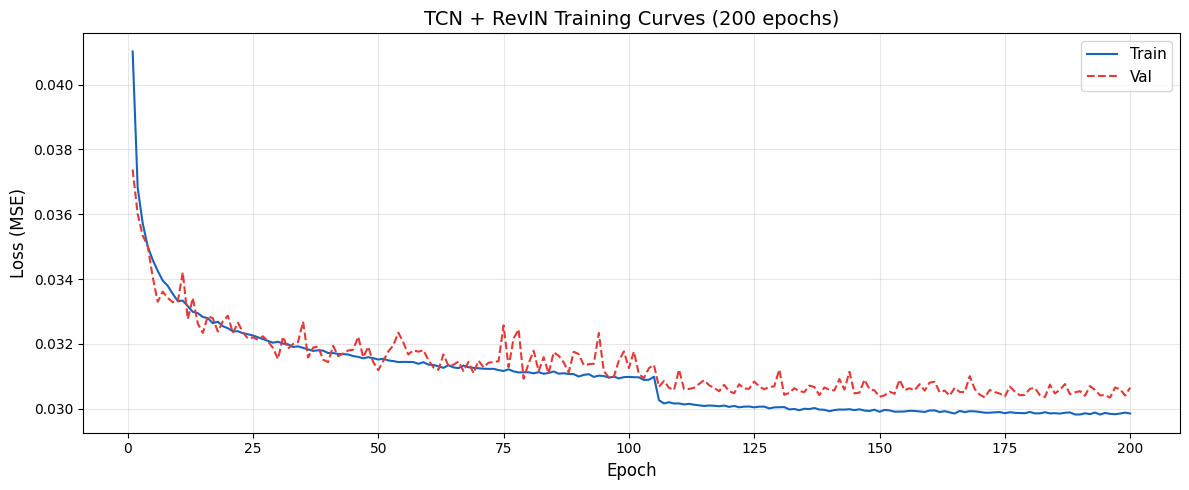

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
ep = range(1, len(history['train_loss']) + 1)
ax.plot(ep, history['train_loss'], label='Train', linewidth=1.5, color='#1565C0')
ax.plot(ep, history['val_loss'], label='Val', linewidth=1.5,
        color='#E53935', linestyle='--')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (MSE)', fontsize=12)
ax.set_title(f'TCN + RevIN Training Curves ({len(history["train_loss"])} epochs)',
             fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'training_curves.png'), dpi=200, bbox_inches='tight')
plt.show()

## 8 — Per-Step RMSE Analysis

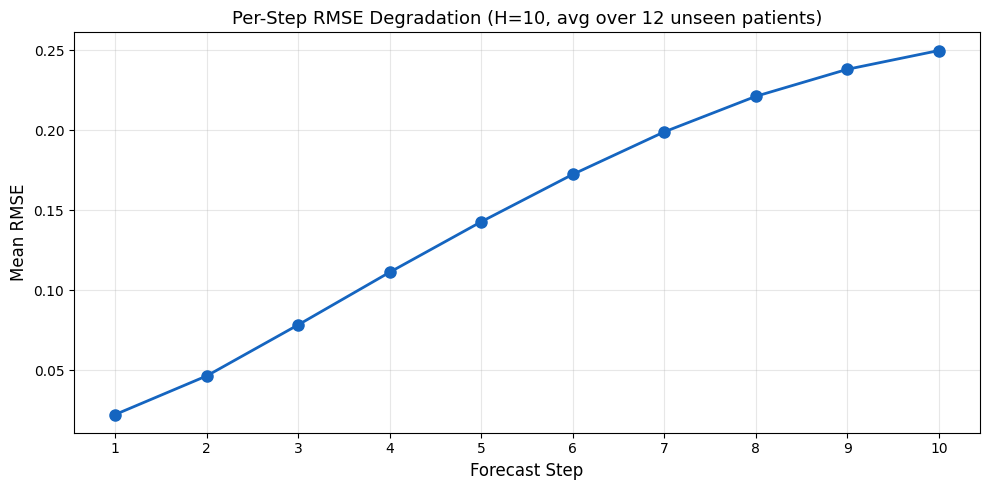

 Step       RMSE
    1   0.022223
    2   0.046378
    3   0.078312
    4   0.111204
    5   0.142756
    6   0.172369
    7   0.198941
    8   0.221171
    9   0.238068
   10   0.249803


In [15]:
# ── Per-step RMSE averaged over all test patients ─────────────────────────────
step_rmse = np.zeros(HORIZON)
for rid in TEST_PATIENTS:
    y_true, y_pred = predictions[rid]
    for h in range(HORIZON):
        step_rmse[h] += np.sqrt(mean_squared_error(
            y_true[:, h], y_pred[:, h]))
step_rmse /= len(TEST_PATIENTS)

fig, ax = plt.subplots(figsize=(10, 5))
steps = range(1, HORIZON + 1)
ax.plot(steps, step_rmse, 'o-', color='#1565C0', linewidth=2, markersize=8)
ax.set_xlabel('Forecast Step', fontsize=12)
ax.set_ylabel('Mean RMSE', fontsize=12)
ax.set_title(f'Per-Step RMSE Degradation (H={HORIZON}, '
             f'avg over {len(TEST_PATIENTS)} unseen patients)', fontsize=13)
ax.set_xticks(steps)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'per_step_rmse.png'), dpi=200, bbox_inches='tight')
plt.show()

print(f'{"Step":>5} {"RMSE":>10}')
for h in range(HORIZON):
    print(f'{h+1:>5} {step_rmse[h]:>10.6f}')

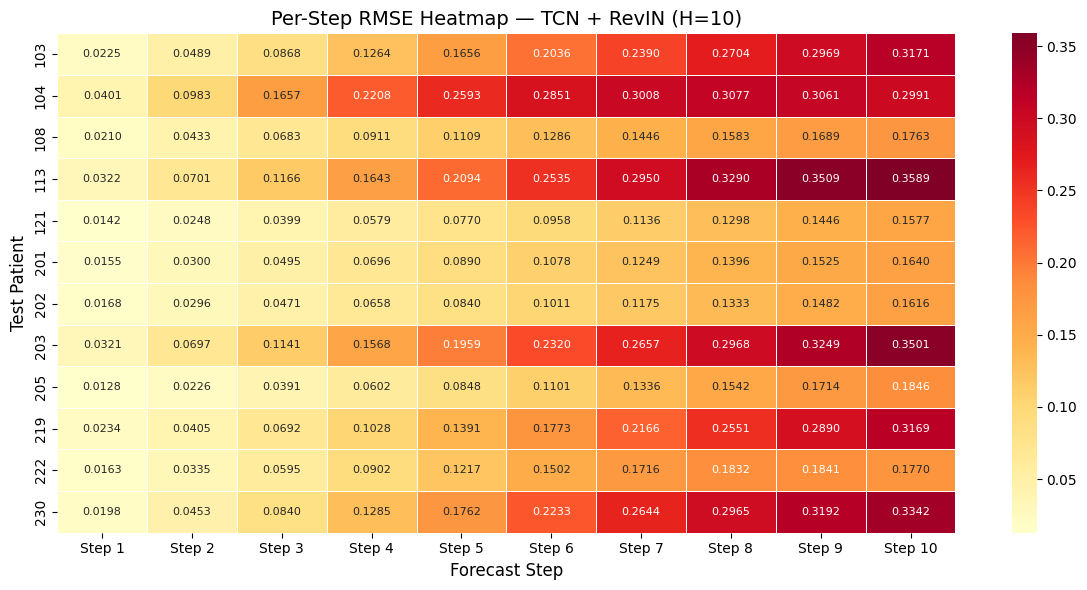

In [16]:
# ── Per-Step RMSE Heatmap (all test patients) ─────────────────────────────────
step_rmse_matrix = np.zeros((len(TEST_PATIENTS), HORIZON))
for i, rid in enumerate(TEST_PATIENTS):
    y_true, y_pred = predictions[rid]
    for h in range(HORIZON):
        step_rmse_matrix[i, h] = np.sqrt(mean_squared_error(
            y_true[:, h], y_pred[:, h]))

fig, ax = plt.subplots(figsize=(12, max(6, len(TEST_PATIENTS) * 0.5)))
sns.heatmap(step_rmse_matrix, annot=True, fmt='.4f', cmap='YlOrRd',
            xticklabels=[f'Step {i+1}' for i in range(HORIZON)],
            yticklabels=TEST_PATIENTS, ax=ax, linewidths=0.5,
            annot_kws={'fontsize': 8})
ax.set_xlabel('Forecast Step', fontsize=12)
ax.set_ylabel('Test Patient', fontsize=12)
ax.set_title(f'Per-Step RMSE Heatmap — TCN + RevIN (H={HORIZON})', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'per_step_rmse_heatmap.png'),
            dpi=200, bbox_inches='tight')
plt.show()

## 9 — Signal Overlay Plots (Test Patients)

Actual vs Predicted for unseen test patients — showing RevIN handles distribution shift.

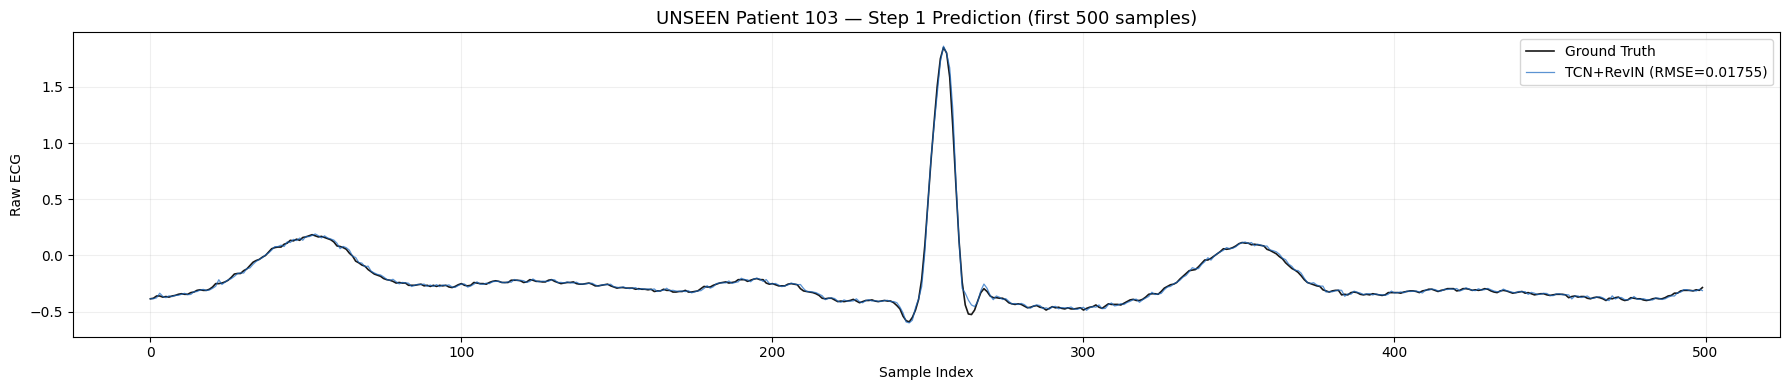

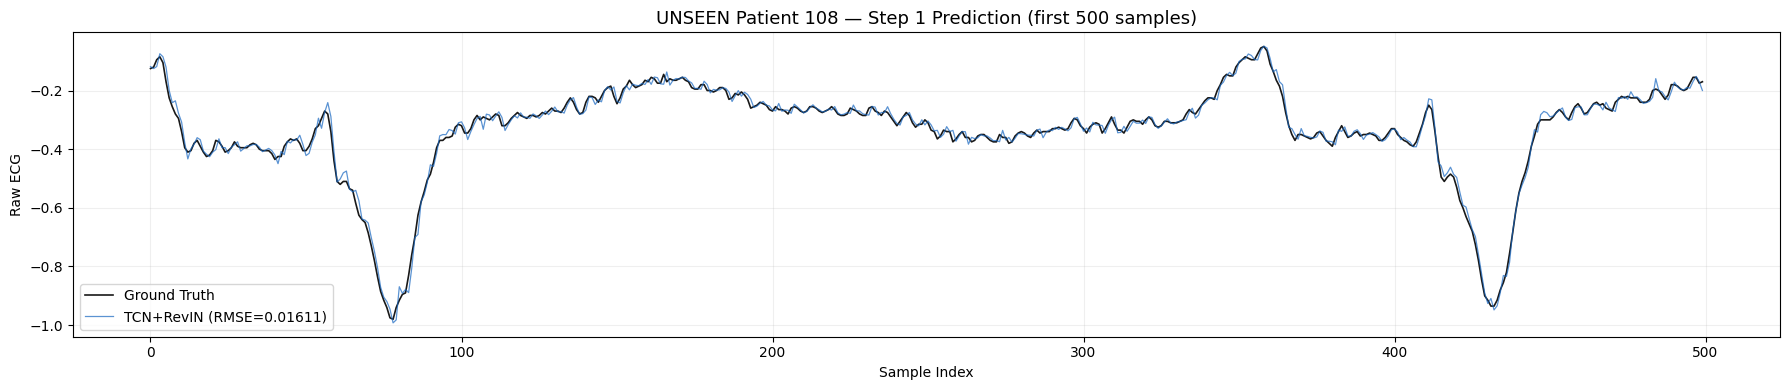

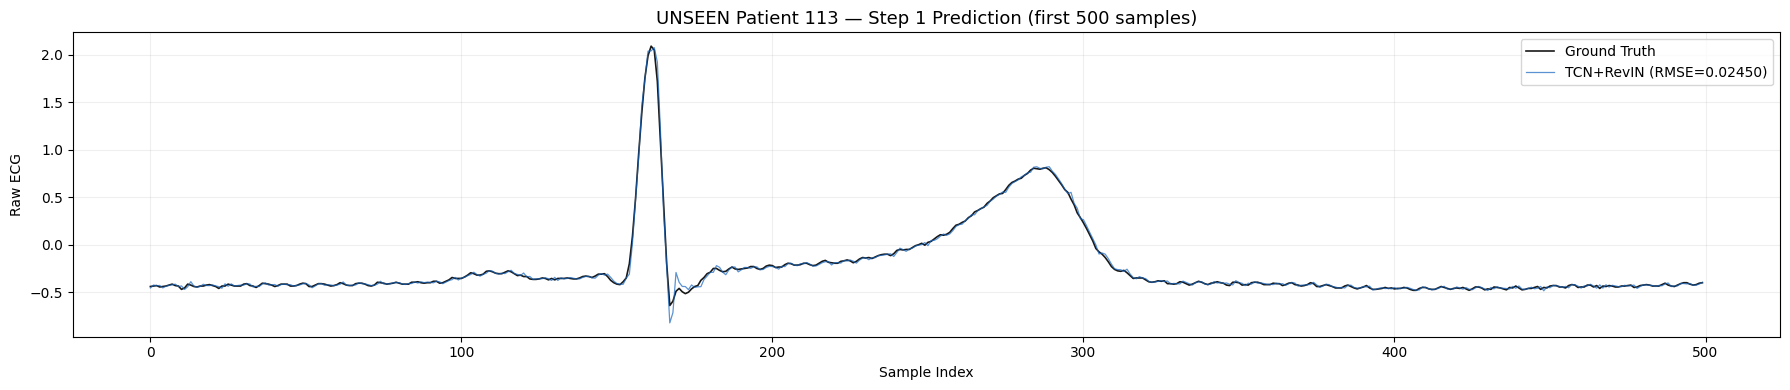

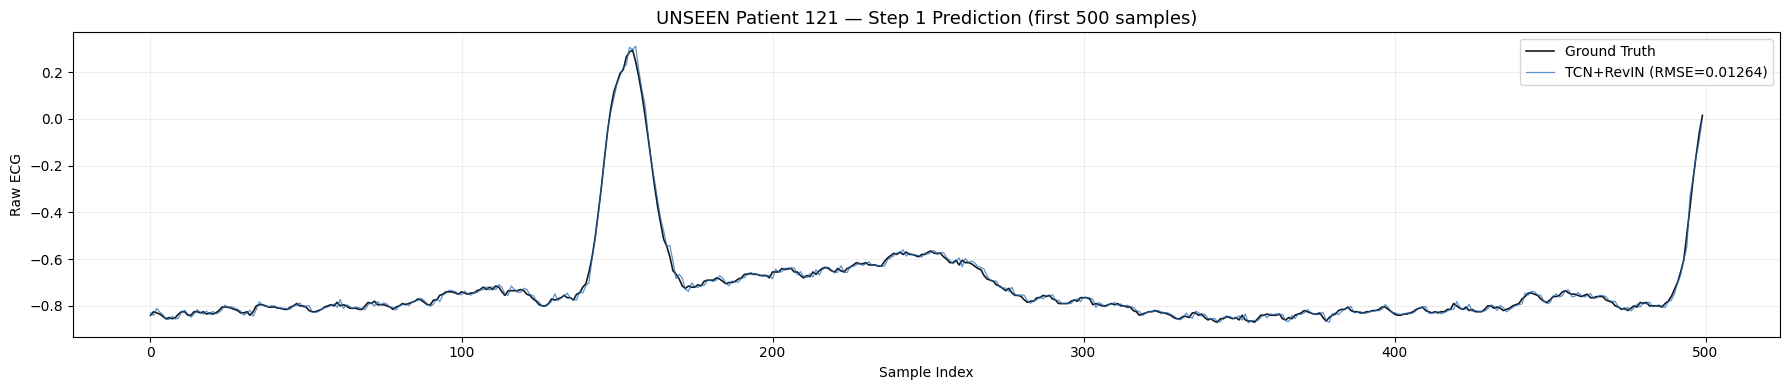

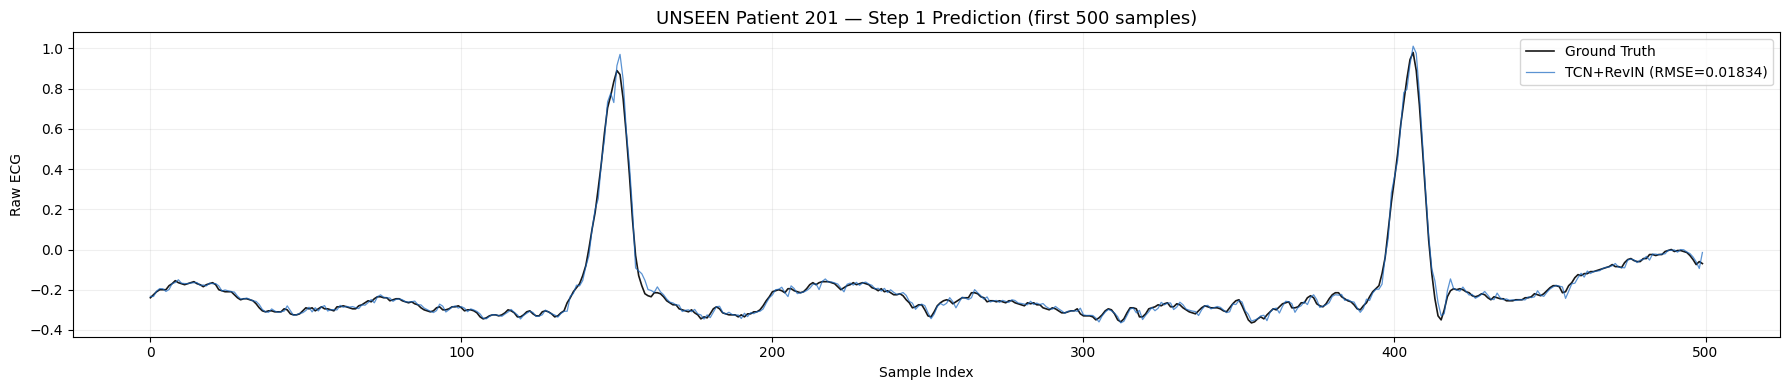

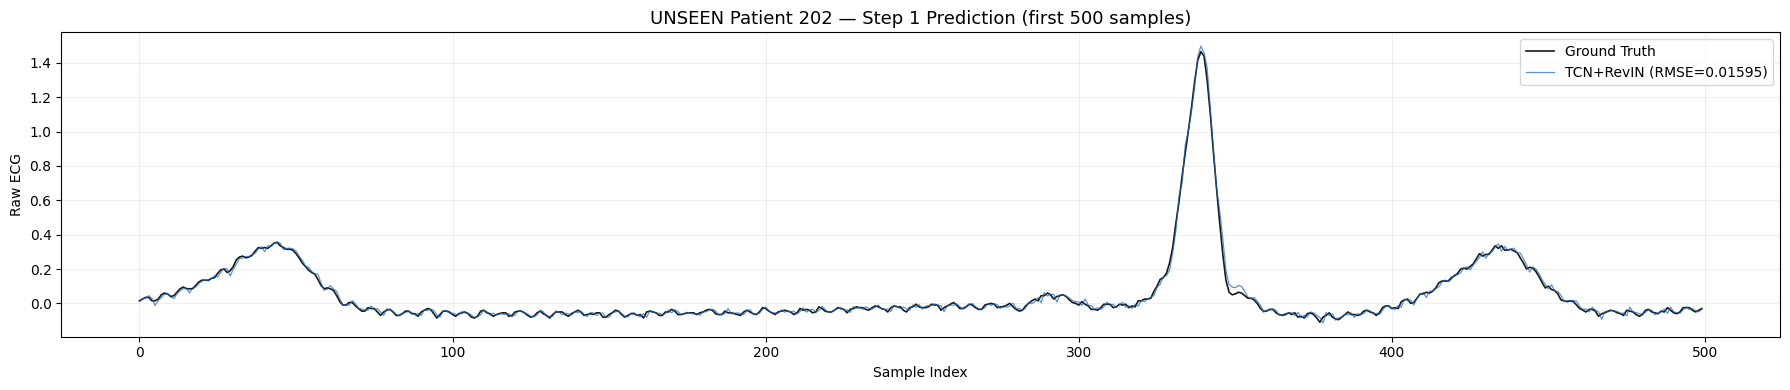

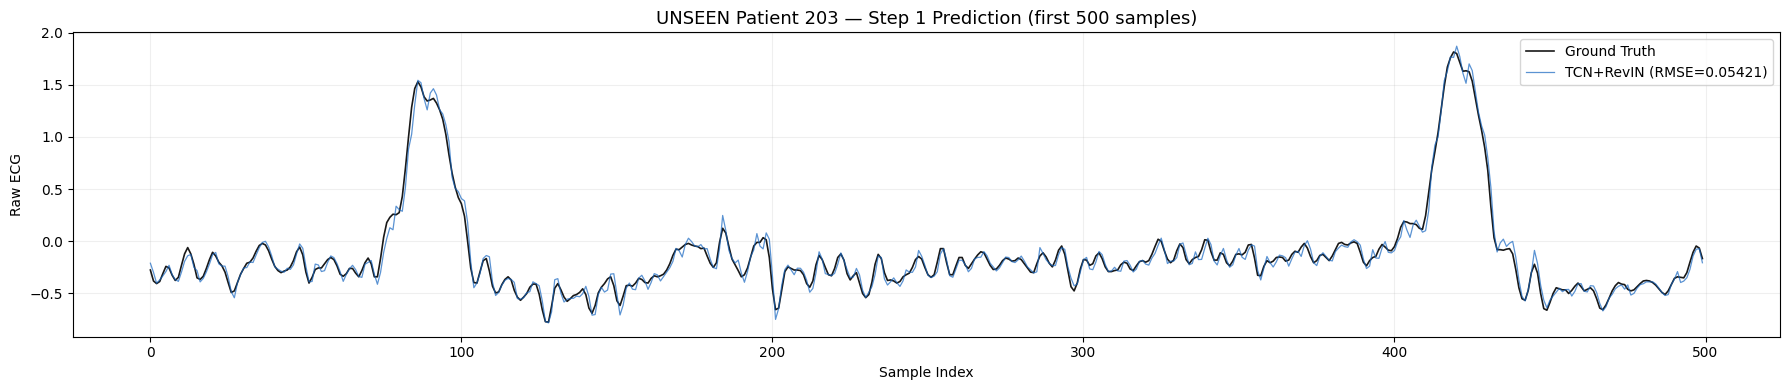

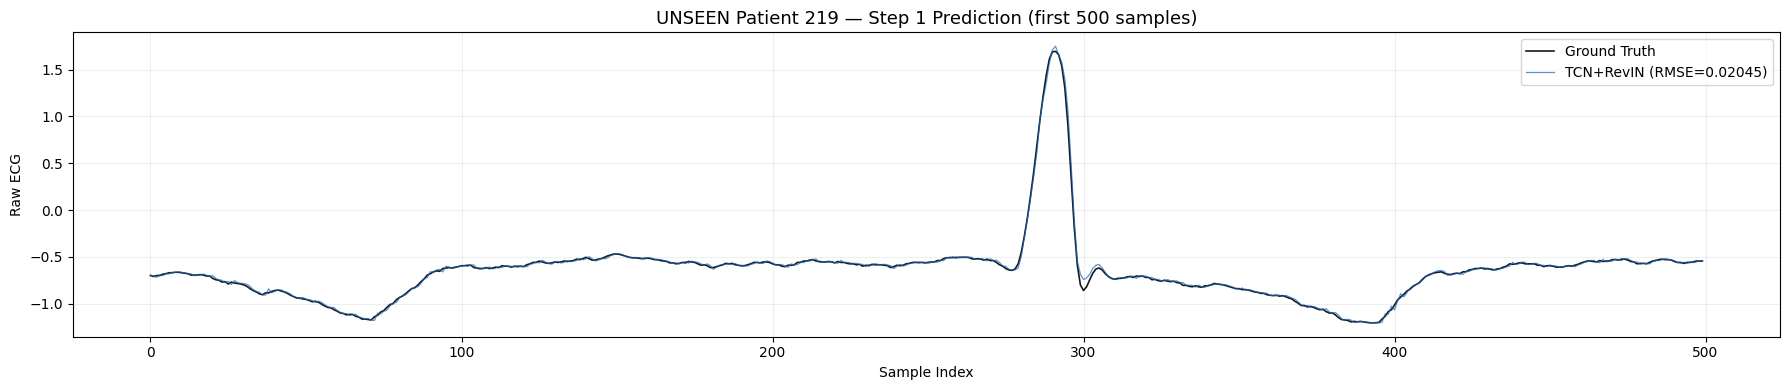

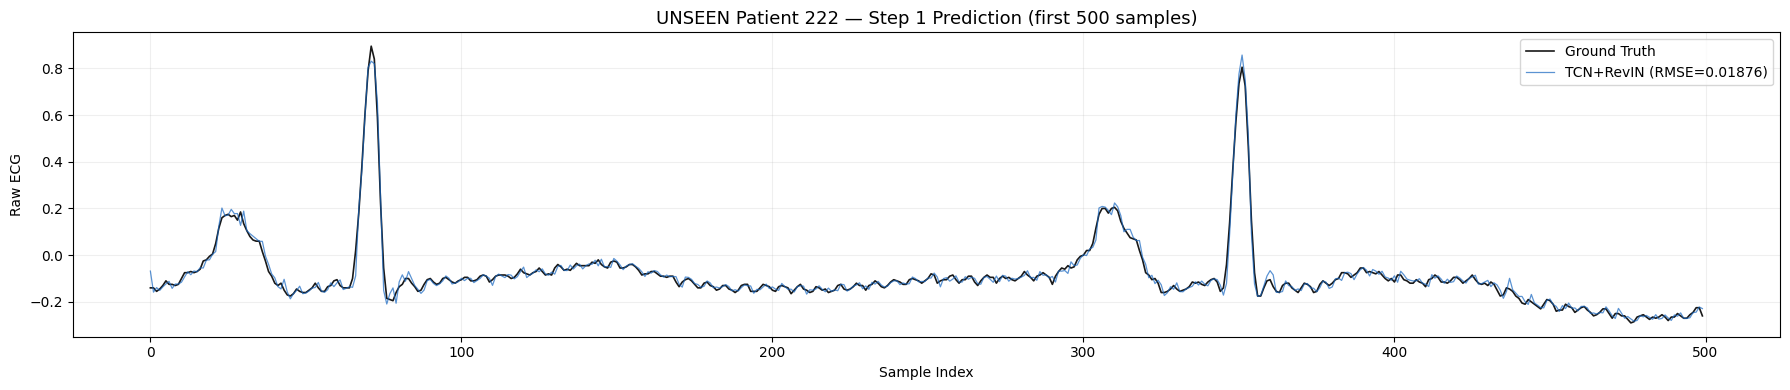

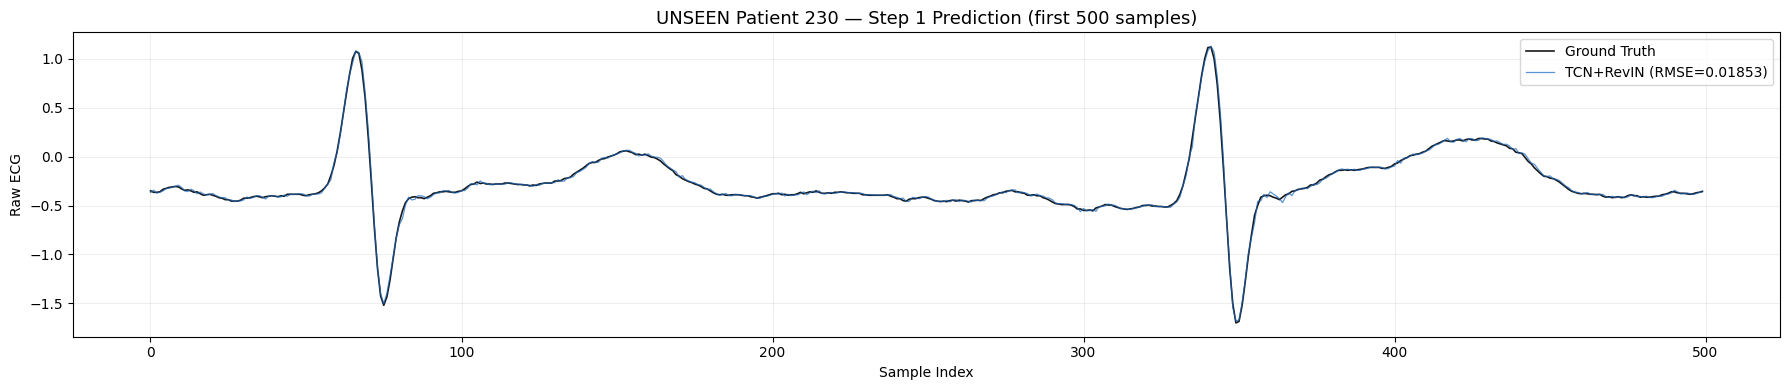

In [17]:
# ── 9.1 Signal overlay — Step 1 ──────────────────────────────────────────────
N_SHOW = 500

for rid in VIZ_PATIENTS:
    y_true, y_pred = predictions[rid]
    actual    = y_true[:N_SHOW, 0]
    predicted = y_pred[:N_SHOW, 0]
    rmse_p = float(np.sqrt(mean_squared_error(actual, predicted)))

    fig, ax = plt.subplots(figsize=(18, 4))
    ax.plot(actual, color='black', linewidth=1.2, label='Ground Truth', alpha=0.9)
    ax.plot(predicted, color='#1565C0', linewidth=0.9,
            label=f'TCN+RevIN (RMSE={rmse_p:.5f})', alpha=0.7)
    ax.set_title(f'UNSEEN Patient {rid} — Step 1 Prediction (first {N_SHOW} samples)',
                 fontsize=13)
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Raw ECG')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f'signal_overlay_{rid}_step1.png'),
                dpi=200, bbox_inches='tight')
    plt.show()

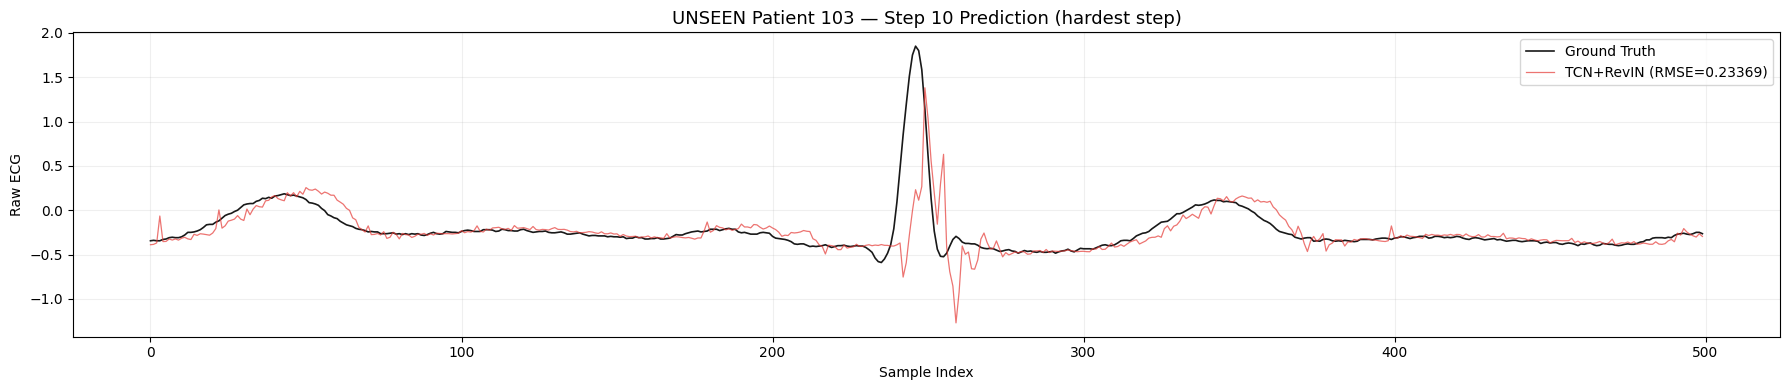

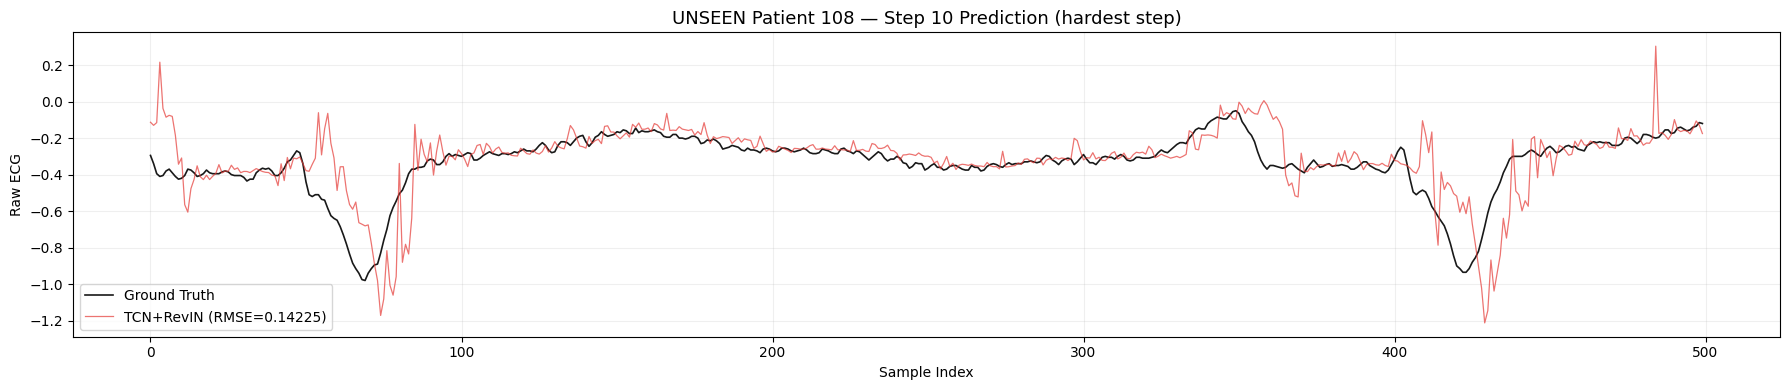

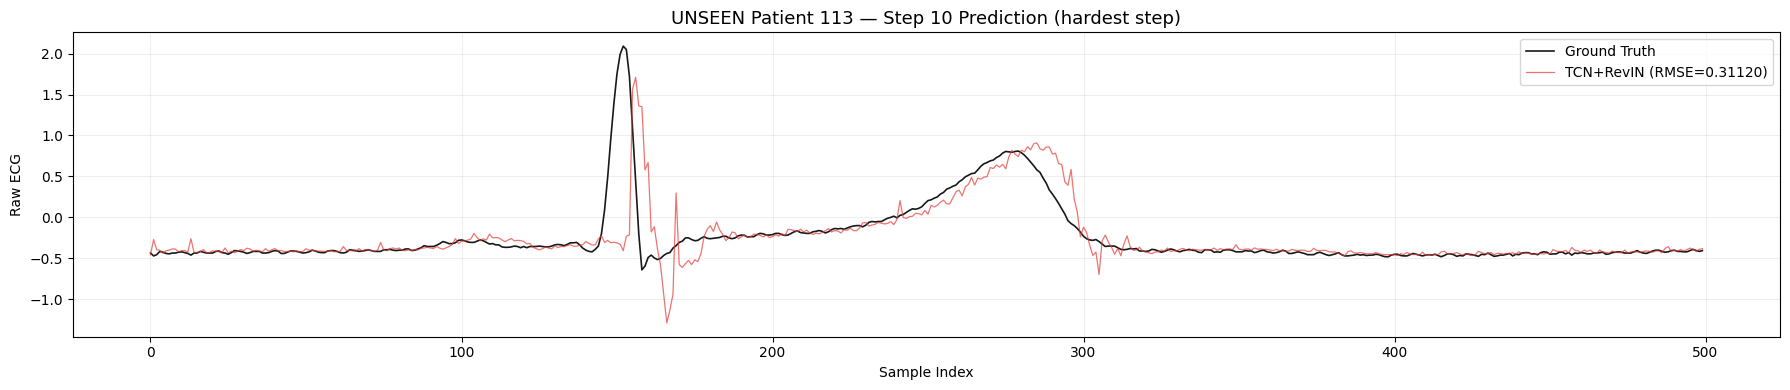

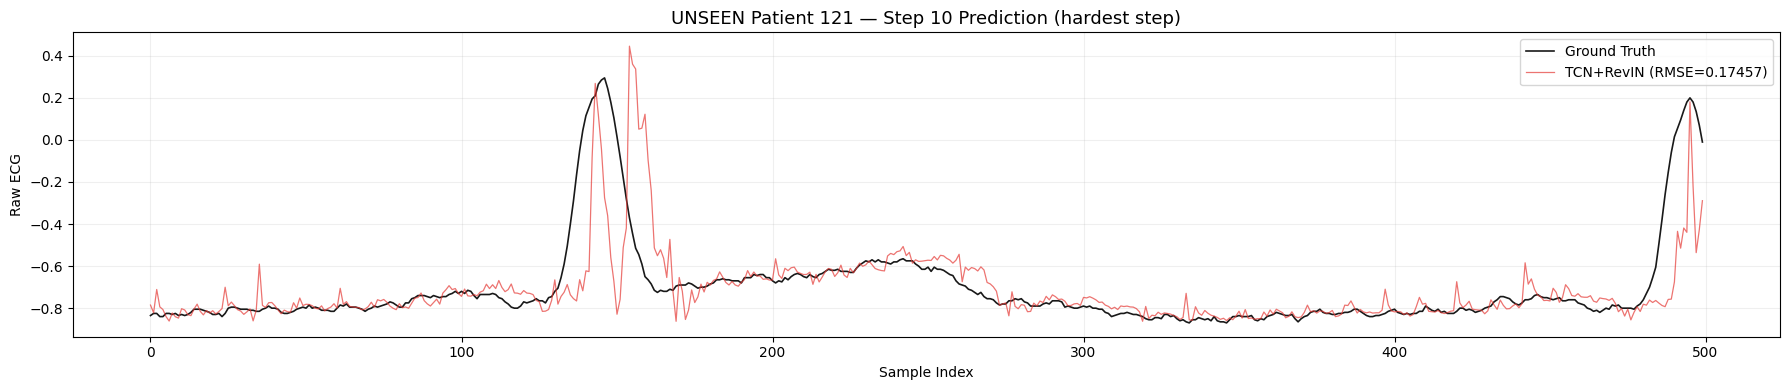

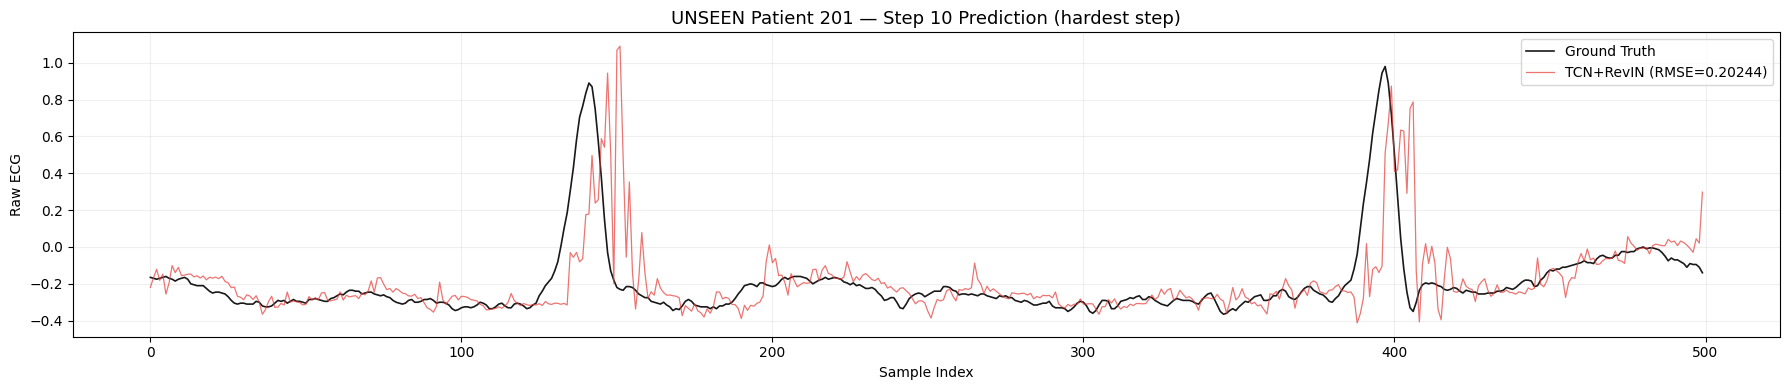

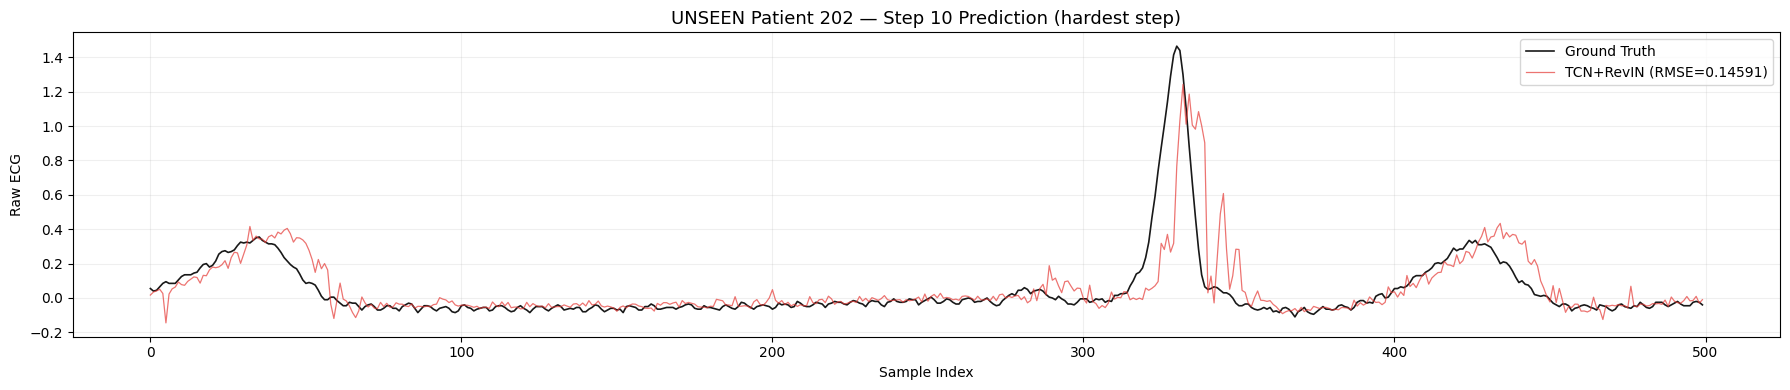

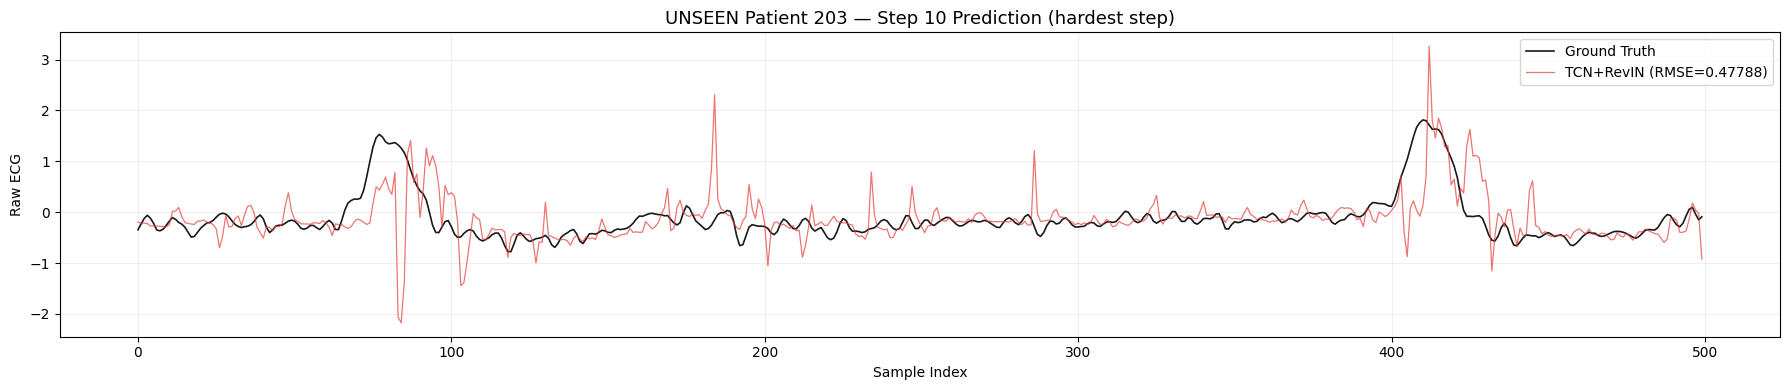

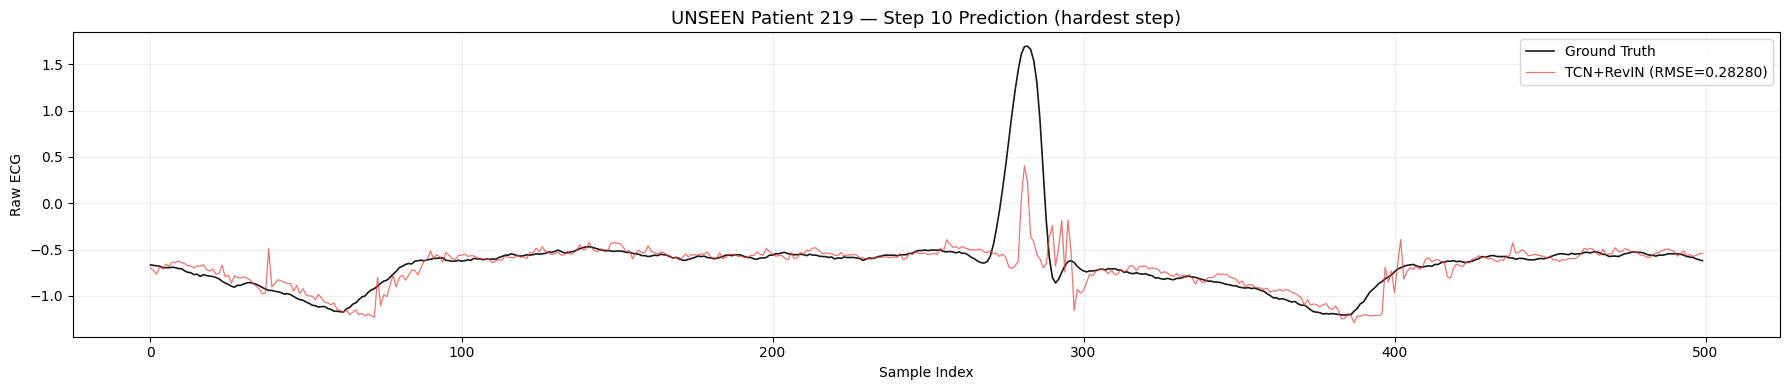

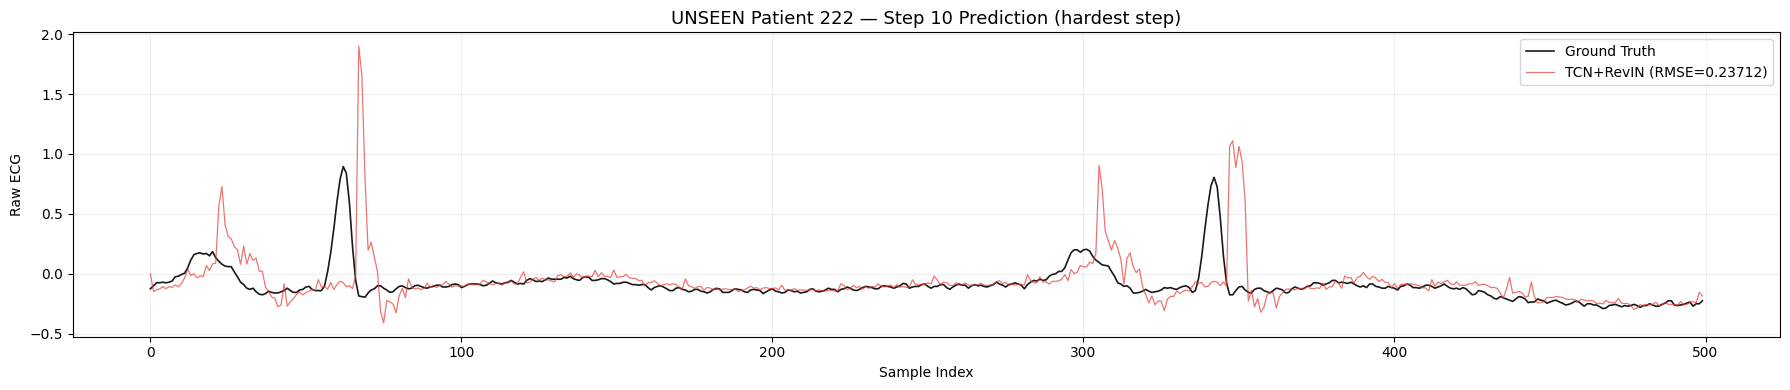

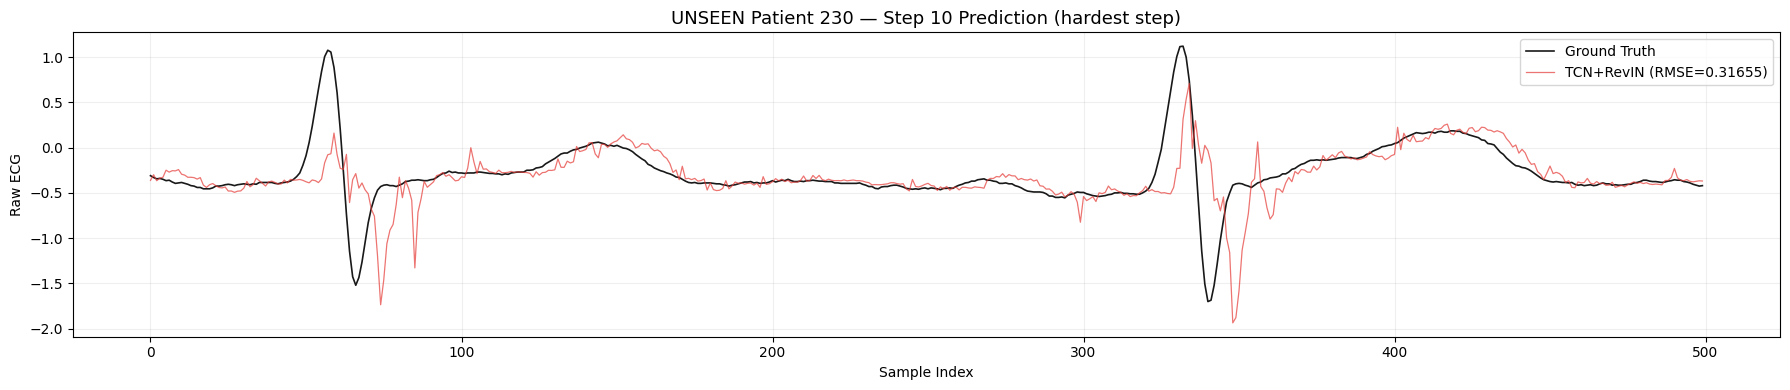

In [18]:
# ── 9.2 Signal overlay — Step 10 (hardest) ───────────────────────────────────
for rid in VIZ_PATIENTS:
    y_true, y_pred = predictions[rid]
    actual    = y_true[:N_SHOW, -1]
    predicted = y_pred[:N_SHOW, -1]
    rmse_p = float(np.sqrt(mean_squared_error(actual, predicted)))

    fig, ax = plt.subplots(figsize=(18, 4))
    ax.plot(actual, color='black', linewidth=1.2, label='Ground Truth', alpha=0.9)
    ax.plot(predicted, color='#E53935', linewidth=0.9,
            label=f'TCN+RevIN (RMSE={rmse_p:.5f})', alpha=0.7)
    ax.set_title(f'UNSEEN Patient {rid} — Step {HORIZON} Prediction (hardest step)',
                 fontsize=13)
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Raw ECG')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f'signal_overlay_{rid}_step{HORIZON}.png'),
                dpi=200, bbox_inches='tight')
    plt.show()

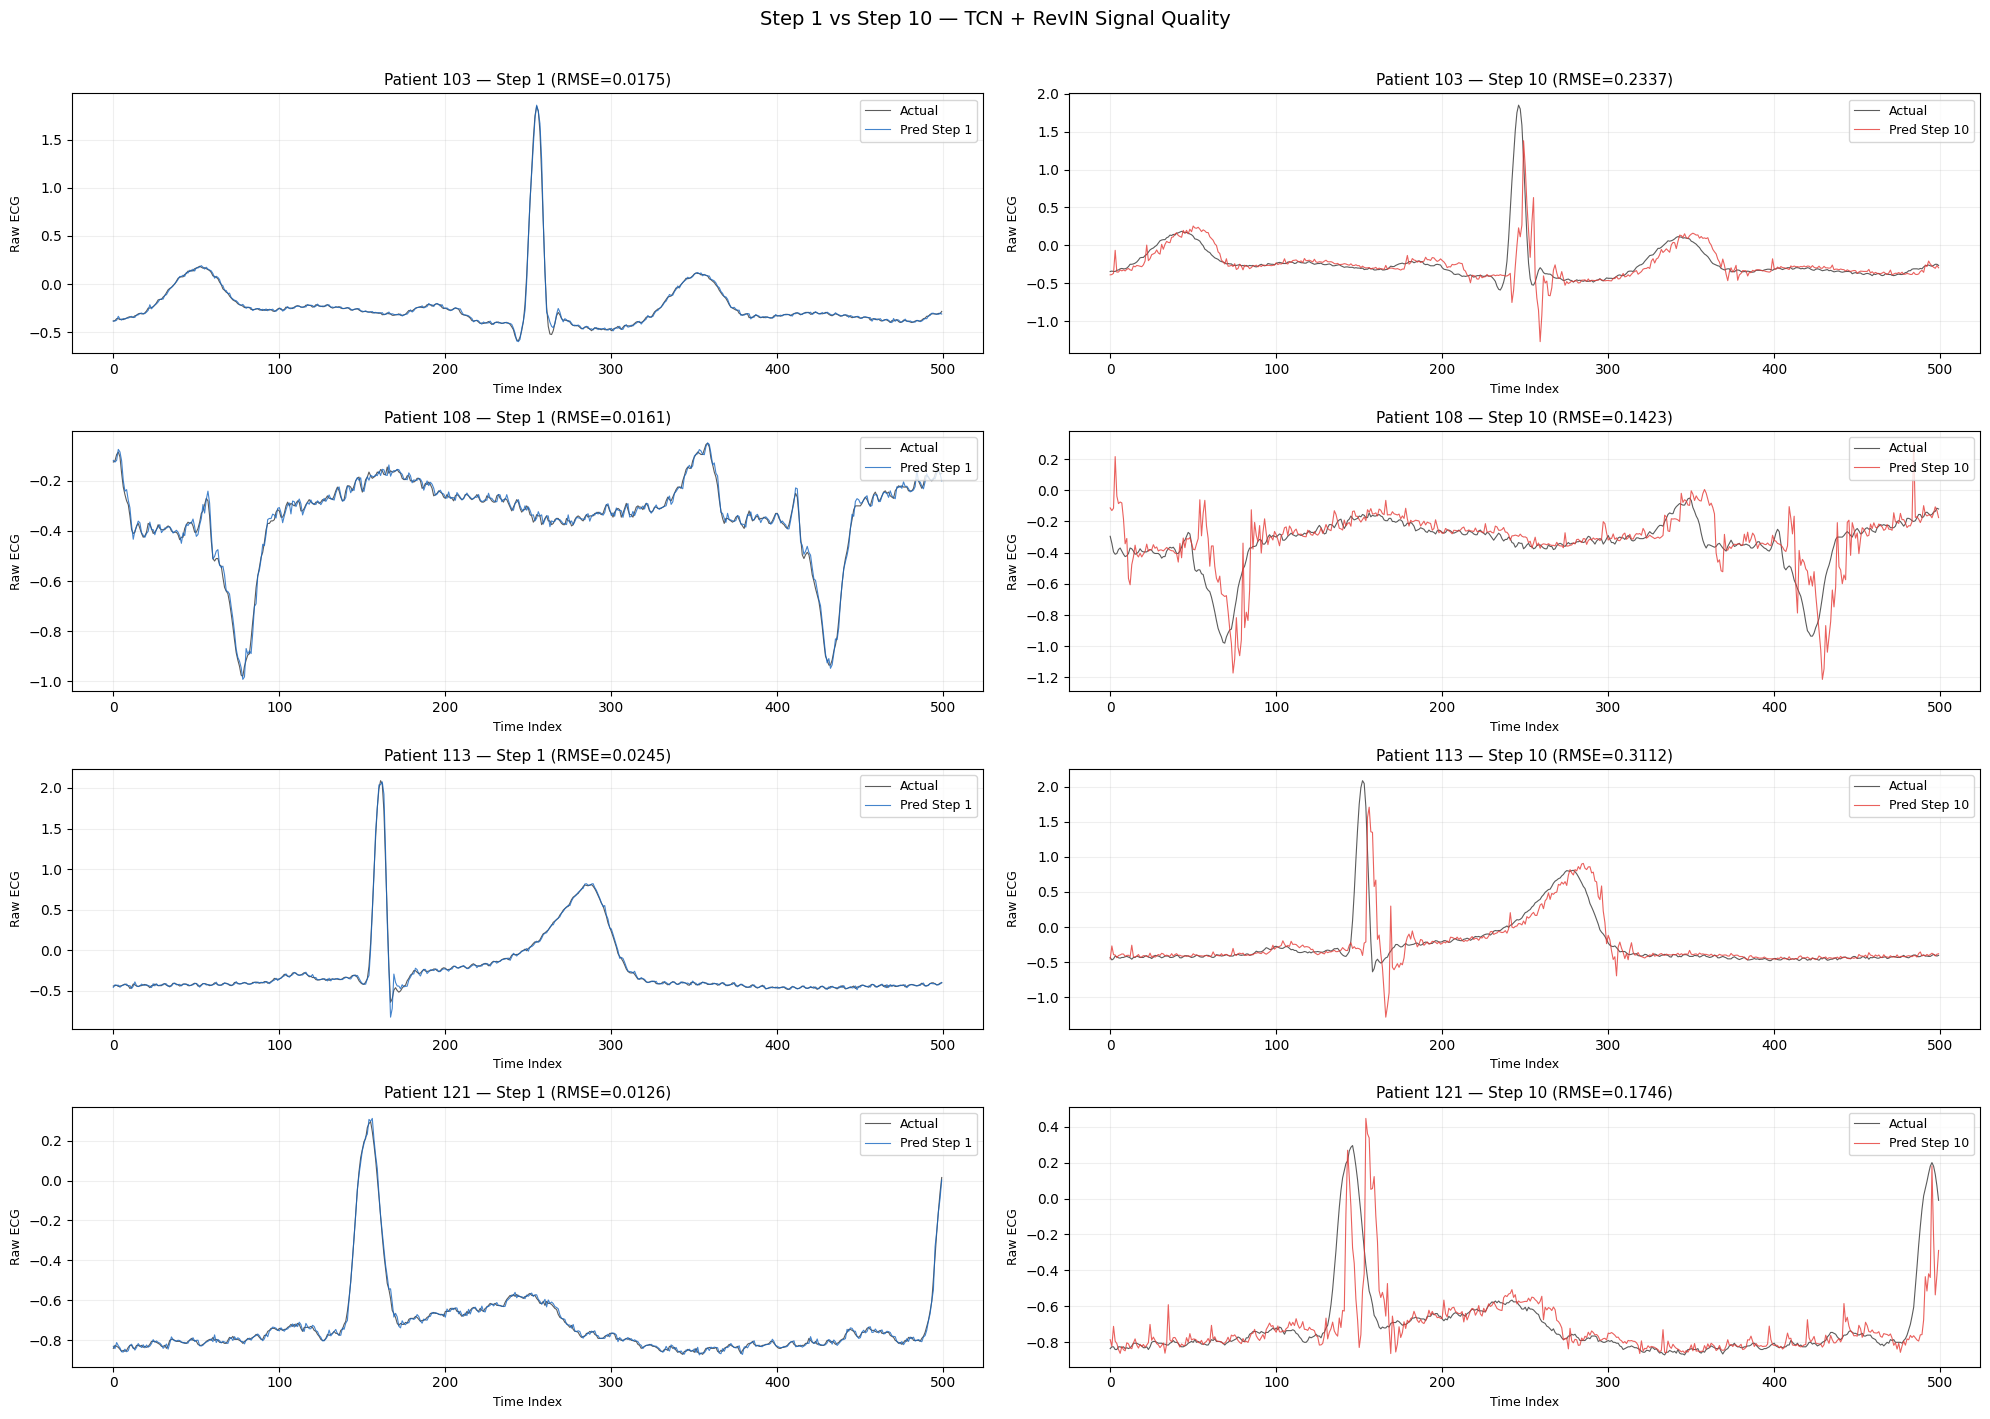

In [19]:
# ── 9.3 Step 1 vs Step 10 Side-by-Side (4 patients) ──────────────────────────
sample_4 = VIZ_PATIENTS[:4]

fig, axes = plt.subplots(len(sample_4), 2, figsize=(20, 14))

for row_idx, rid in enumerate(sample_4):
    y_true, y_pred = predictions[rid]
    for col_idx, (step_idx, step_label, color) in enumerate([
        (0, 'Step 1', '#1565C0'),
        (HORIZON - 1, f'Step {HORIZON}', '#E53935'),
    ]):
        ax = axes[row_idx, col_idx]
        actual    = y_true[:N_SHOW, step_idx]
        predicted = y_pred[:N_SHOW, step_idx]
        rmse_p = float(np.sqrt(mean_squared_error(actual, predicted)))

        ax.plot(actual, color='#333333', linewidth=0.8, alpha=0.8, label='Actual')
        ax.plot(predicted, color=color, linewidth=0.8, alpha=0.8,
                label=f'Pred {step_label}')
        ax.set_title(f'Patient {rid} — {step_label} (RMSE={rmse_p:.4f})', fontsize=11)
        ax.set_xlabel('Time Index', fontsize=9)
        ax.set_ylabel('Raw ECG', fontsize=9)
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(alpha=0.2)

plt.suptitle(f'Step 1 vs Step {HORIZON} — TCN + RevIN Signal Quality',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'signal_step1_vs_step10.png'),
            dpi=200, bbox_inches='tight')
plt.show()

## 10 — Distribution Shift Visualization

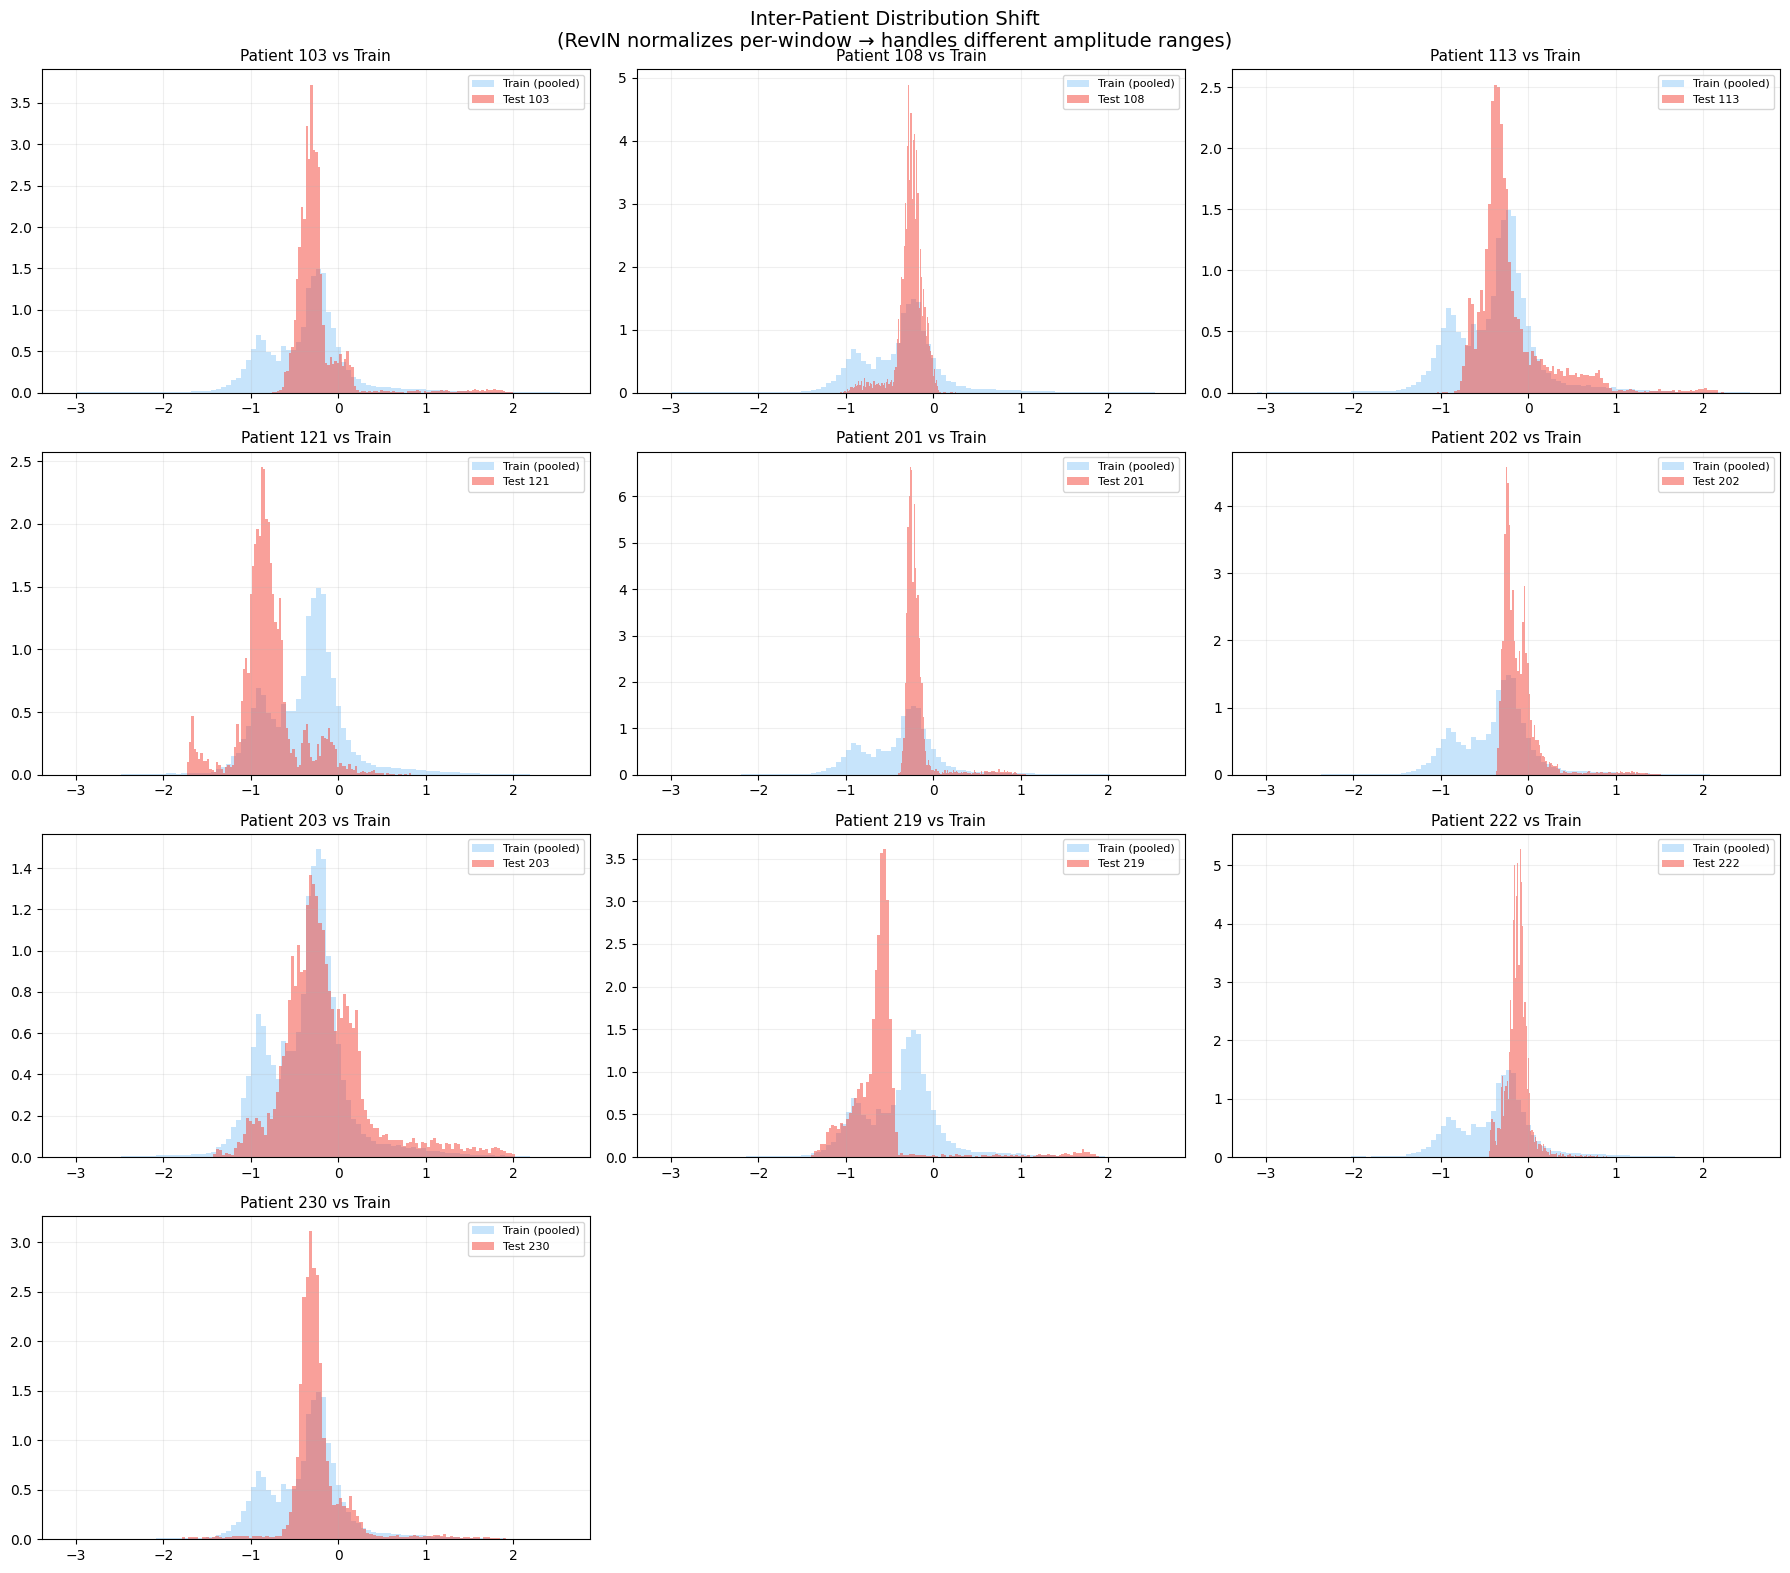

In [20]:
# ── Show how test patients' distributions differ from train ───────────────────
train_pool_sample = np.concatenate(
    [raw_signals[rid][:10000] for rid in TRAIN_PATIENTS])

n_viz_dist = min(len(VIZ_PATIENTS), 12)
nc_dist = min(3, n_viz_dist)
nr_dist = int(np.ceil(n_viz_dist / nc_dist))

fig, axes = plt.subplots(nr_dist, nc_dist, figsize=(6 * nc_dist, 4 * nr_dist))
if nr_dist == 1 and nc_dist == 1:
    axes = np.array([axes])
axes_flat = axes.flatten()

for idx, rid in enumerate(VIZ_PATIENTS[:n_viz_dist]):
    ax = axes_flat[idx]
    test_sig = raw_signals[rid]

    ax.hist(train_pool_sample, bins=100, alpha=0.5, density=True,
            label='Train (pooled)', color='#90CAF9')
    ax.hist(test_sig[:10000], bins=100, alpha=0.5, density=True,
            label=f'Test {rid}', color='#F44336')
    ax.set_title(f'Patient {rid} vs Train', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

for idx in range(n_viz_dist, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle('Inter-Patient Distribution Shift\n'
             '(RevIN normalizes per-window → handles different amplitude ranges)',
             fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'distribution_shift.png'),
            dpi=200, bbox_inches='tight')
plt.show()

## 11 — Error Distribution

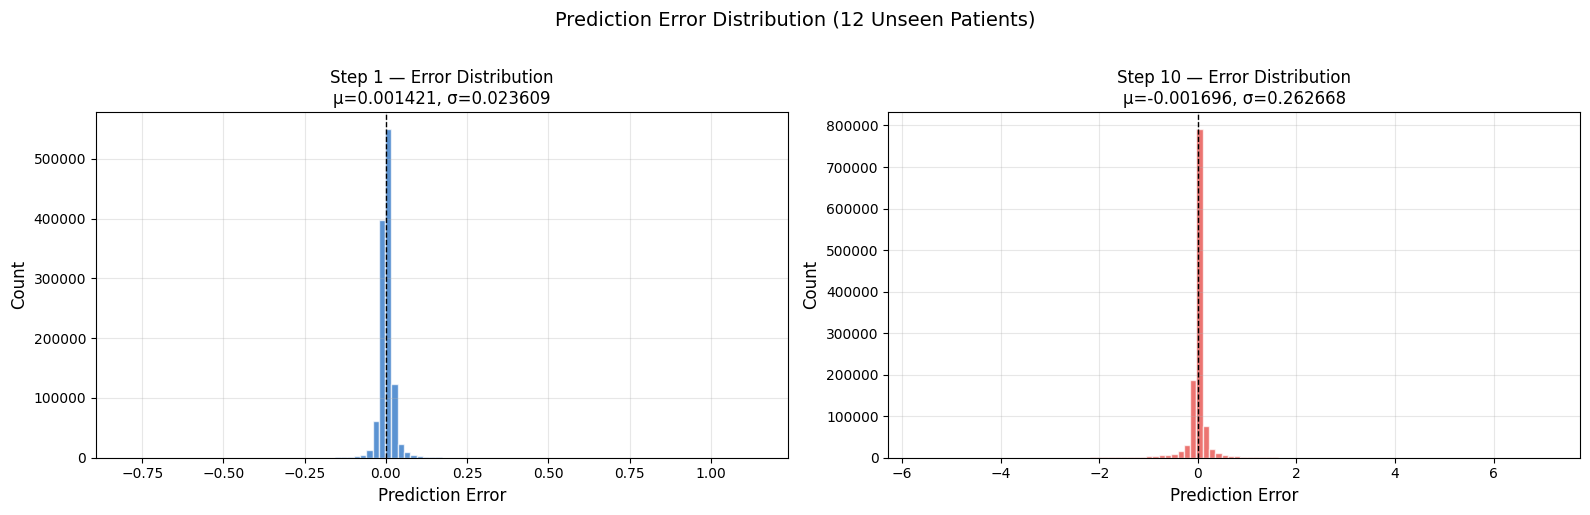

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, step_idx, step_label, color in [
    (axes[0], 0, 'Step 1', '#1565C0'),
    (axes[1], HORIZON - 1, f'Step {HORIZON}', '#E53935'),
]:
    all_errors = []
    for rid in TEST_PATIENTS:
        y_true, y_pred = predictions[rid]
        errors = y_pred[:, step_idx] - y_true[:, step_idx]
        all_errors.append(errors)
    all_errors = np.concatenate(all_errors)

    ax.hist(all_errors, bins=100, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(x=0, color='black', linewidth=1, linestyle='--')
    ax.set_xlabel('Prediction Error', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(f'{step_label} — Error Distribution\n'
                 f'μ={all_errors.mean():.6f}, σ={all_errors.std():.6f}',
                 fontsize=12)
    ax.grid(alpha=0.3)

plt.suptitle(f'Prediction Error Distribution ({len(TEST_PATIENTS)} Unseen Patients)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'error_distribution.png'),
            dpi=200, bbox_inches='tight')
plt.show()

## 12 — Final Summary

In [22]:
print('=' * 70)
print('  INTER-PATIENT TCN + RevIN (PyTorch) — FINAL RESULTS')
print('=' * 70)
print(f'\n  Setup     : Train on {len(TRAIN_PATIENTS)} patients, '
      f'test on {len(TEST_PATIENTS)} UNSEEN patients')
print(f'  Total     : {len(ALL_PATIENTS)} MIT-BIH patients (all)')
print(f'  Horizon   : H={HORIZON}')
print(f'  Framework : PyTorch {torch.__version__}')
print(f'  Device    : {DEVICE}')
print(f'  TCN Config: blocks={NUM_BLOCKS}, filters={NUM_FILTERS}, '
      f'dropout={DROPOUT_RATE}, lr={LEARNING_RATE}')
print(f'  RevIN     : per-window normalization (Kim et al., ICLR 2022)')
print(f'  Source    : MOGWO Pareto-best (Eval 28)')
print(f'  No MinMax : RevIN handles distribution shift at runtime')
print()
print(f'  Results (H={HORIZON}, {len(TEST_PATIENTS)} unseen patients):')
print(f'    Mean RMSE = {df_results.RMSE.mean():.6f} ± {df_results.RMSE.std():.6f}')
print(f'    Mean MAE  = {df_results.MAE.mean():.6f} ± {df_results.MAE.std():.6f}')
print(f'    Mean R²   = {df_results.R2.mean():.4f} ± {df_results.R2.std():.4f}')
print(f'    Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'    Train time: {train_time:.1f}s ({ep_trained} epochs)')
print()
print(f'  Outputs saved to {OUT_DIR}/')
print(f'  Plots saved to {PLOT_DIR}/')
print('=' * 70)

  INTER-PATIENT TCN + RevIN (PyTorch) — FINAL RESULTS

  Setup     : Train on 36 patients, test on 12 UNSEEN patients
  Total     : 48 MIT-BIH patients (all)
  Horizon   : H=10
  Framework : PyTorch 2.10.0+cu128
  Device    : cuda
  TCN Config: blocks=3, filters=128, dropout=0.131, lr=0.00451
  RevIN     : per-window normalization (Kim et al., ICLR 2022)
  Source    : MOGWO Pareto-best (Eval 28)
  No MinMax : RevIN handles distribution shift at runtime

  Results (H=10, 12 unseen patients):
    Mean RMSE = 0.167493 ± 0.059707
    Mean MAE  = 0.064299 ± 0.022567
    Mean R²   = 0.6284 ± 0.2126
    Parameters: 266,508
    Train time: 33574.5s (200 epochs)

  Outputs saved to /kaggle/working/
  Plots saved to /kaggle/working/plots_inter_tcn_revin_pytorch/
